# NLP and Deep Learning for Text Classification in Medical Diagnosis

## Research Question

RQ1: What is the effectiveness of the NLP algorithm in classifying patient symptoms from the text data on the population level?
- **H10**: Text analysis of patient symptoms results in insufficient precision and recall for provider decision support.
- **H1a**: Text analysis of patient symptoms results in precision and recall sufficient for provider decision support.

## Overview

This notebook implements a complete text classification pipeline to analyze medical symptom descriptions and classify them into appropriate diagnostic categories. We'll evaluate multiple NLP approaches and deep learning models to determine which provides the best performance for medical symptom classification.

## 1. Environment Setup

Import all necessary libraries for our analysis. This includes data manipulation, visualization, NLP, machine learning and deep learning tools.

In [156]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import re
import string
import os
import warnings
from wordcloud import WordCloud
from PIL import Image

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from textblob import TextBlob
import textstat

# Machine learning libraries
import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, GlobalMaxPooling1D, Conv1D, MaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# Suppress warnings
warnings.filterwarnings('ignore')

# Download NLTK resources
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('corpora/stopwords')
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('punkt')
    nltk.download('stopwords')
    nltk.download('wordnet')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure visualization settings
plt.style.use('fivethirtyeight')
sns.set(style='whitegrid')

# Display versions of key libraries
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

Pandas version: 2.0.2
NumPy version: 1.23.5
TensorFlow version: 2.12.0
Scikit-learn version: 1.0.2


[nltk_data] Downloading package punkt to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 2. Data Loading and Exploration

**Purpose:** Load the dataset and explore its structure. Focus on the key fields for our analysis: 'phrase' (patient descriptions) and 'prompt' (diagnostic categories).

In [157]:
# Define the dataset path
data_path = r'G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\data\Medical Speech, Transcription, and Intent\overview-of-recordings.csv'

# Load the dataset
df = pd.read_csv(data_path)

# Define key fields for analysis as specified
key_fields = ['phrase', 'prompt']

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"\nDataset columns: {df.columns.tolist()}")
print(f"\nKey fields for analysis: {key_fields}")

# Display the first few rows of the dataset focused on our key fields
print("\nSample data (first 5 rows):")
df[key_fields].head()

Dataset shape: (6661, 13)

Dataset columns: ['audio_clipping', 'audio_clipping:confidence', 'background_noise_audible', 'background_noise_audible:confidence', 'overall_quality_of_the_audio', 'quiet_speaker', 'quiet_speaker:confidence', 'speaker_id', 'file_download', 'file_name', 'phrase', 'prompt', 'writer_id']

Key fields for analysis: ['phrase', 'prompt']

Sample data (first 5 rows):


,phrase,prompt
0,When I remember her I feel down,Emotional pain
1,When I carry heavy things I feel like breaking...,Hair falling out
2,there is too much pain when i move my arm,Heart hurts
3,My son had his lip pierced and it is swollen a...,Infected wound
4,My muscles in my lower back are aching,Infected wound


### 2.1 Data Cleaning (Data Quality Check)

**Purpose:** Check for missing values, duplicates, and other data quality issues in our key fields.

In [158]:
# Check for missing values in key fields
print("Missing values in key fields:")
print(df[key_fields].isna().sum())

# Check for duplicates in phrases
duplicates = df.duplicated(subset=['phrase']).sum()
print(f"\nDuplicate phrases: {duplicates}")

# Check class distribution (diagnostic categories)
print("\nClass distribution (top 10 diagnostic categories):")
class_distribution = df['prompt'].value_counts()
print(class_distribution.head(10))

# Calculate class imbalance statistics
total_classes = len(class_distribution)
print(f"\nTotal number of unique diagnostic categories: {total_classes}")

# Check statistics on text length
df['phrase_length'] = df['phrase'].str.len()
print("\nText length statistics:")
print(df['phrase_length'].describe())

# Remove temporary column
df.drop('phrase_length', axis=1, inplace=True)

Missing values in key fields:
phrase    0
prompt    0
dtype: int64

Duplicate phrases: 5955

Class distribution (top 10 diagnostic categories):
prompt
Acne              328
Shoulder pain     320
Joint pain        318
Infected wound    306
Knee pain         305
Cough             293
Feeling dizzy     283
Muscle pain       282
Heart hurts       273
Ear ache          270
Name: count, dtype: int64

Total number of unique diagnostic categories: 25

Text length statistics:
count    6661.000000
mean       50.026122
std        23.672184
min         9.000000
25%        33.000000
50%        45.000000
75%        61.000000
max       155.000000
Name: phrase_length, dtype: float64


### 2.2 Data Visualization

**Purpose:** Visualize the class distribution and text characteristics to gain a better understanding of our dataset.

In [159]:
# Visualize class distribution (top 15 categories)
top_n = 15
top_categories = class_distribution.head(top_n).reset_index()
top_categories.columns = ['Category', 'Count']

fig = px.bar(top_categories, x='Category', y='Count', 
             title=f'Distribution of Top {top_n} Diagnostic Categories',
             color='Count', color_continuous_scale='viridis')
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.show()

# Calculate text length
df['text_length'] = df['phrase'].apply(len)
df['word_count'] = df['phrase'].apply(lambda x: len(str(x).split()))

# Visualize text length distribution
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=('Distribution of Text Length (Characters)', 
                                  'Distribution of Word Count'))

fig.add_trace(
    go.Histogram(x=df['text_length'], nbinsx=30, marker_color='blue'),
    row=1, col=1
)

fig.add_trace(
    go.Histogram(x=df['word_count'], nbinsx=30, marker_color='green'),
    row=1, col=2
)

fig.update_layout(height=500, width=1000, title_text="Text Length Analysis")
fig.show()

# Remove temporary columns
df.drop(['text_length', 'word_count'], axis=1, inplace=True)

## 3. Text Data Preprocessing

**Purpose:** Transforming the cleaned text data into a format suitable for machine learning algorithms.

### 3.1 Define Basic Text Cleaning Function

**Purpose:** To clean the raw text data by converting it to lowercase, replacing contractions, removing special characters, and extra whitespaces.

In [160]:
def clean_text(text):
    """Basic text cleaning function"""
    if isinstance(text, str):  # Check if text is a string
        # Convert to lowercase
        text = text.lower()
        
        # Replace contractions
        text = re.sub(r"what's", "what is", text)
        text = re.sub(r"'s", " is", text)
        text = re.sub(r"'ve", " have", text)
        text = re.sub(r"can't", "cannot", text)
        text = re.sub(r"n't", " not", text)
        text = re.sub(r"'re", " are", text)
        text = re.sub(r"'d", " would", text)
        text = re.sub(r"'ll", " will", text)
        text = re.sub(r"'t", " not", text)
        
        # Remove special characters and digits
        text = re.sub(r"[^a-zA-Z\s]", "", text)
        
        # Remove extra whitespaces
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    else:
        return ""

### 3.2 Initialize NLTK Components

**Purpose:** Set up the necessary tools for advanced preprocessing, such as stopword lists and lemmatizers.

In [161]:
# Initialize NLTK components
stop_words = set(stopwords.words('english'))
medical_stopwords_to_keep = {'pain', 'ache', 'fever', 'swelling', 'rash'}
filtered_stop_words = stop_words - medical_stopwords_to_keep  # Keep important medical terms
lemmatizer = WordNetLemmatizer()

### 3.3 Define Advanced Preprocessing Function

**Purpose:** Combine basic cleaning with tokenization, stopword removal, and lemmatization for more refined text processing.

1. **Tokenization:** This involves breaking down a sentence or paragraph into smaller units, which can be words, punctuation marks, or other meaningful units.

2. **Stopword Removal:** This step removes common words that don't add much meaning to the text and can be noise for analysis. Examples include "the," "a," "an," "is," and "are."

3. **Lemmatization:** This reduces words to their root form, ensuring that "feeling," "felt," and "feels" are all reduced to "run." It also considers the word's context and part of speech, making it more accurate than stemming.

In [162]:
def advanced_preprocess(text):
    """Advanced preprocessing with tokenization, stopword removal, and lemmatization"""
    if not isinstance(text, str) or len(text) == 0:
        return ""
    
    # Basic cleaning first
    text = clean_text(text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in filtered_stop_words]
    
    # Rejoin tokens
    processed_text = ' '.join(tokens)
    
    return processed_text

### 3.4 Process the Text Data

**Purpose:** Apply the cleaning and advanced preprocessing functions to the specified column of the DataFrame and create new columns for cleaned and processed text.

In [163]:
# Process the text data
print("Preprocessing text data...")
df['clean_phrase'] = df['phrase'].apply(clean_text)
df['processed_phrase'] = df['phrase'].apply(advanced_preprocess)

Preprocessing text data...


### 3.5 Display Sample Results

**Purpose:** Show a random sample of original, cleaned, and processed text to verify the effectiveness of the preprocessing steps.

In [164]:
# Display samples of original and processed text
print("\nSample text preprocessing results:")
sample_idx = np.random.randint(0, len(df), 5)
for idx in sample_idx:
    print(f"\nOriginal: {df.iloc[idx]['phrase']}")
    print(f"Cleaned: {df.iloc[idx]['clean_phrase']}")
    print(f"Processed: {df.iloc[idx]['processed_phrase']}")


Sample text preprocessing results:

Original: My shoulder has agreat pain
Cleaned: my shoulder has agreat pain
Processed: shoulder agreat pain

Original: I have a sharp pain in my neck
Cleaned: i have a sharp pain in my neck
Processed: sharp pain neck

Original: I have acne in my face and other problema in my derma like itching
Cleaned: i have acne in my face and other problema in my derma like itching
Processed: acne face problema derma like itching

Original: There is an injured person
Cleaned: there is an injured person
Processed: injured person

Original: I can't carry anything I have a pain in my shoulder
Cleaned: i cannot carry anything i have a pain in my shoulder
Processed: carry anything pain shoulder


## 4. Feature Engineering

**Purpose:** Transforming the preprocessed text into numerical features that machine learning models can understand.

### 4.1 Define the Function for Extracting Text Features

**Purpose:** Create a function extract_text_features that captures various linguistic features (sentiment polarity, sentiment subjectivity, text complexity) from the text.

In [165]:
def extract_text_features(text):
    """
    Extract sophisticated linguistic features from text for enhanced classification
    
    Args:
        text (str): The input text to analyze
        
    Returns:
        pandas.Series: A row of features ready to be combined with the main dataset
    """
    if not isinstance(text, str) or len(text) == 0:
        return pd.Series({'sentiment_polarity': 0, 'sentiment_subjectivity': 0, 'text_complexity': 0})
    
    # Sentiment Analysis using TextBlob
    blob = TextBlob(text)
    sentiment_polarity = blob.sentiment.polarity
    sentiment_subjectivity = blob.sentiment.subjectivity
    
    # Text Complexity Analysis
    try:
        text_complexity = textstat.flesch_reading_ease(text)
    except:
        text_complexity = 0
    
    return pd.Series({
        'sentiment_polarity': sentiment_polarity,
        'sentiment_subjectivity': sentiment_subjectivity,
        'text_complexity': text_complexity
    })

 ### 4.2 Extract Additional Text Features

 **Purpose:** Apply the feature extraction function to the cleaned text data and add the features to the DataFrame.

In [166]:
print("Extracting additional text features...")
additional_features = df['clean_phrase'].apply(extract_text_features)
df = pd.concat([df, additional_features], axis=1)

Extracting additional text features...


### 4.3 Encode the Target Variable

**Purpose:** Use LabelEncoder to encode the target variable (prompt) into a numerical format for classification tasks.

In [167]:
print("\nEncoding target variable...")
label_encoder = LabelEncoder()
df['prompt_encoded'] = label_encoder.fit_transform(df['prompt'])

# Save the mapping of encoded labels
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"\nNumber of classes: {len(label_mapping)}")

# Print out the initial classes
print(f"\nInitial classes (diagnostic categories):")
print("="*50)
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{i:2d}: {class_name}")

print(f"\nLabel mapping (class name -> encoded value):")
print("="*50)
for class_name, encoded_value in sorted(label_mapping.items()):
    print(f"'{class_name}' -> {encoded_value}")

# Show class distribution with encoded values
print(f"\nClass distribution with encoded values:")
print("="*45)
class_dist_encoded = df['prompt_encoded'].value_counts().sort_index()
for encoded_value, count in class_dist_encoded.items():
    class_name = label_encoder.inverse_transform([encoded_value])[0]
    print(f"Class {encoded_value:2d} ({class_name}): {count} samples")


Encoding target variable...

Number of classes: 25

Initial classes (diagnostic categories):
 0: Acne
 1: Back pain
 2: Blurry vision
 3: Body feels weak
 4: Cough
 5: Ear ache
 6: Emotional pain
 7: Feeling cold
 8: Feeling dizzy
 9: Foot ache
10: Hair falling out
11: Hard to breath
12: Head ache
13: Heart hurts
14: Infected wound
15: Injury from sports
16: Internal pain
17: Joint pain
18: Knee pain
19: Muscle pain
20: Neck pain
21: Open wound
22: Shoulder pain
23: Skin issue
24: Stomach ache

Label mapping (class name -> encoded value):
'Acne' -> 0
'Back pain' -> 1
'Blurry vision' -> 2
'Body feels weak' -> 3
'Cough' -> 4
'Ear ache' -> 5
'Emotional pain' -> 6
'Feeling cold' -> 7
'Feeling dizzy' -> 8
'Foot ache' -> 9
'Hair falling out' -> 10
'Hard to breath' -> 11
'Head ache' -> 12
'Heart hurts' -> 13
'Infected wound' -> 14
'Injury from sports' -> 15
'Internal pain' -> 16
'Joint pain' -> 17
'Knee pain' -> 18
'Muscle pain' -> 19
'Neck pain' -> 20
'Open wound' -> 21
'Shoulder pain' -> 2

### 4.4 Split the Data into Training, Validation, and Testing Sets

**Purpose:** Divide the processed text data and encoded labels into training, validation, and testing datasets using stratified sampling to maintain class distribution across all splits.

- **Training Set (64%):** Used to train the model parameters
- **Validation Set (16%):** Used for hyperparameter tuning and model selection during development
- **Testing Set (20%):** Used for final model evaluation on completely unseen data

This three-way split helps prevent overfitting and provides a robust evaluation framework by ensuring the model is tested on data it has never seen during training or validation.

In [168]:
X = df['processed_phrase']
y = df['prompt_encoded']

# First split: separate test set (20% of total data)
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: create validation set from remaining training data (20% of remaining 80% = 16% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.2, random_state=42, stratify=y_train_temp
)

print(f"Total dataset size: {len(X)}")
print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set size: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify class distribution across splits
print(f"\nClass distribution verification:")
print(f"Original: {np.bincount(y) / len(y) * 100}")
print(f"Training: {np.bincount(y_train) / len(y_train) * 100}")
print(f"Validation: {np.bincount(y_val) / len(y_val) * 100}")
print(f"Testing: {np.bincount(y_test) / len(y_test) * 100}")

Total dataset size: 6661
Training set size: 4262 (64.0%)
Validation set size: 1066 (16.0%)
Testing set size: 1333 (20.0%)

Class distribution verification:
Original: [4.92418556 3.88830506 3.69313917 3.61807536 4.39873893 4.05344543
 3.46794776 3.9483561  4.24861132 3.34784567 3.96336886 3.49797328
 3.9483561  4.09848371 4.59390482 3.45293499 3.72316469 4.77405795
 4.57889206 4.23359856 3.76820297 3.12265426 4.80408347 3.93334334
 3.91833058]
Training: [4.90380103 3.89488503 3.70717973 3.61332708 4.38761145 4.05912717
 3.4725481  3.94181136 4.24683247 3.35523229 3.96527452 3.49601126
 3.94181136 4.08259033 4.59877992 3.44908494 3.70717973 4.76302206
 4.57531675 4.24683247 3.77756922 3.14406382 4.80994838 3.94181136
 3.91834819]
Validation: [4.97185741 3.84615385 3.65853659 3.65853659 4.40900563 4.03377111
 3.47091932 3.93996248 4.22138837 3.37711069 3.93996248 3.47091932
 3.93996248 4.12757974 4.59662289 3.47091932 3.75234522 4.78424015
 4.59662289 4.22138837 3.75234522 3.0956848  4.78

### 4.5 Feature Extraction Using TF-IDF Vectorizer

**Purpose:** Create a TF-IDF representation of the training, validation, and testing sets to transform the text data into a suitable format for machine learning models.

In [169]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"\nTF-IDF feature shape:")
print(f"Training: {X_train_tfidf.shape}")
print(f"Validation: {X_val_tfidf.shape}")
print(f"Testing: {X_test_tfidf.shape}")


TF-IDF feature shape:
Training: (4262, 3234)
Validation: (1066, 3234)
Testing: (1333, 3234)


### 4.6 Feature Extraction Using Count Vectorizer

**Purpose:** Similarly, create a Bag of Words (BoW) representation of the text data for comparison with TF-IDF features.

In [170]:
count_vectorizer = CountVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_bow = count_vectorizer.fit_transform(X_train)
X_val_bow = count_vectorizer.transform(X_val)
X_test_bow = count_vectorizer.transform(X_test)

print(f"Bag of Words feature shape:")
print(f"Training: {X_train_bow.shape}")
print(f"Validation: {X_val_bow.shape}")
print(f"Testing: {X_test_bow.shape}")

Bag of Words feature shape:
Training: (4262, 3234)
Validation: (1066, 3234)
Testing: (1333, 3234)


## 5. Model Selection

**Purpose:** Evaluate different machine learning and deep learning algorithms for text classification and select the most suitable one based on initial performance and characteristics.

### 5.1 Machine Learning Models

**Purpose:** Select and configure traditional machine learning models for text classification, including Naive Bayes, Support Vector Machine (SVM), Logistic Regression, and Random Forest with appropriate hyperparameters to prevent overfitting.

In [205]:
# Initialize candidate models with appropriate parameters to avoid overfitting
candidate_models = {
    'Multinomial Naive Bayes': MultinomialNB(alpha=0.1),
    'Support Vector Machine': LinearSVC(C=1.0, max_iter=5000, random_state=42),
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
}

print("Selected Machine Learning Models:")
for name, model in candidate_models.items():
    print(f"✓ {name}: {model.__class__.__name__}")
    
print(f"\nTotal models to evaluate: {len(candidate_models)}")

Selected Machine Learning Models:
✓ Multinomial Naive Bayes: MultinomialNB
✓ Support Vector Machine: LinearSVC
✓ Logistic Regression: LogisticRegression
✓ Random Forest: RandomForestClassifier

Total models to evaluate: 4


#### 5.1.1 ML K-fold Cross Validation

**Purpose:** Evaluate the performance of different ML models on different subsets of the data

Performing K-Fold Cross-Validation...

Evaluating Multinomial Naive Bayes...
F1-Score: 0.9947 (+/- 0.0090)
Individual fold scores: [0.99906149 0.99623976 0.99812096 0.9865618  0.9934064 ]

Evaluating Support Vector Machine...
F1-Score: 0.9947 (+/- 0.0090)
Individual fold scores: [0.99906149 0.99623976 0.99812096 0.9865618  0.9934064 ]

Evaluating Support Vector Machine...
F1-Score: 0.9974 (+/- 0.0038)
Individual fold scores: [1.         0.99718274 0.99906134 0.99531583 0.99529109]

Evaluating Logistic Regression...
F1-Score: 0.9974 (+/- 0.0038)
Individual fold scores: [1.         0.99718274 0.99906134 0.99531583 0.99529109]

Evaluating Logistic Regression...
F1-Score: 0.9961 (+/- 0.0056)
Individual fold scores: [1.         0.99623976 0.99812096 0.99249262 0.99340659]

Evaluating Random Forest...
F1-Score: 0.9961 (+/- 0.0056)
Individual fold scores: [1.         0.99623976 0.99812096 0.99249262 0.99340659]

Evaluating Random Forest...
F1-Score: 0.8570 (+/- 0.0220)
Individual fold scores:

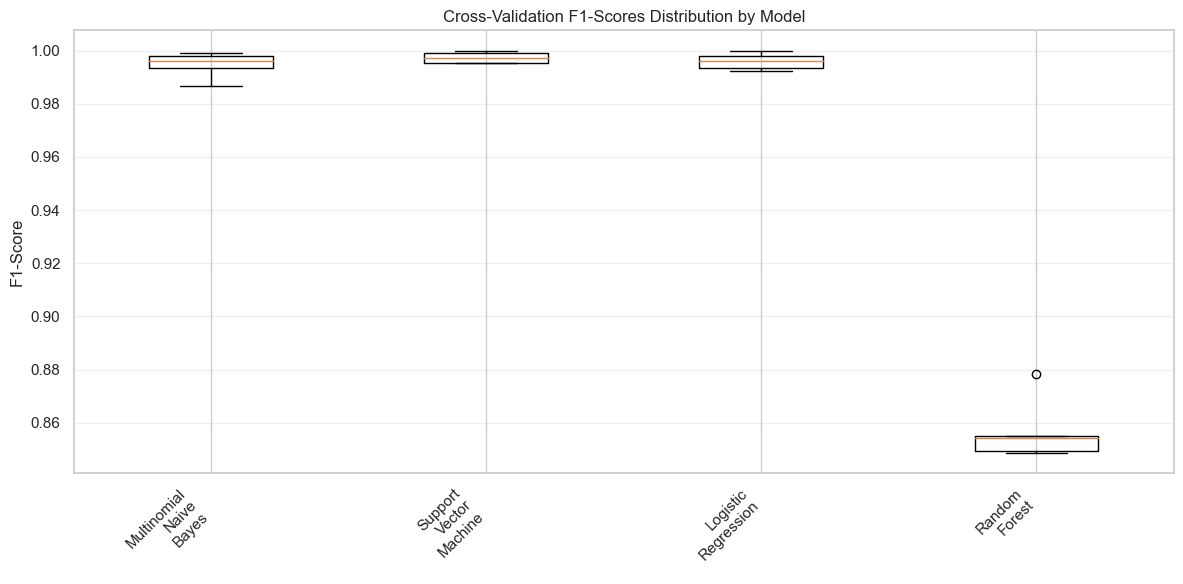


Top 3 models selected for hyperparameter tuning:
1. Support Vector Machine: 0.9974
2. Logistic Regression: 0.9961
3. Multinomial Naive Bayes: 0.9947


In [196]:
# Initialize stratified K-fold cross-validation
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Combine training and validation sets for cross-validation
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

# Transform combined data using TF-IDF
X_train_val_tfidf = tfidf_vectorizer.fit_transform(X_train_val)

# Store cross-validation results
cv_results = {}

print("Performing K-Fold Cross-Validation...")
print("="*60)

for model_name, model in candidate_models.items():
    print(f"\nEvaluating {model_name}...")
    
    # Perform cross-validation
    cv_scores = cross_val_score(model, X_train_val_tfidf, y_train_val, 
                               cv=skf, scoring='f1_weighted', n_jobs=-1)
    
    # Store results
    cv_results[model_name] = {
        'scores': cv_scores,
        'mean': cv_scores.mean(),
        'std': cv_scores.std(),
        'min': cv_scores.min(),
        'max': cv_scores.max()
    }
    
    print(f"F1-Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print(f"Individual fold scores: {cv_scores}")

# Create summary table
cv_summary = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Mean_F1': [results['mean'] for results in cv_results.values()],
    'Std_F1': [results['std'] for results in cv_results.values()],
    'Min_F1': [results['min'] for results in cv_results.values()],
    'Max_F1': [results['max'] for results in cv_results.values()]
}).round(4)

# Sort by mean F1-score
cv_summary = cv_summary.sort_values('Mean_F1', ascending=False)

print(f"\n{k_folds}-Fold Cross-Validation Results Summary:")
print("="*60)
print(cv_summary.to_string(index=False))

# Visualize cross-validation results
plt.figure(figsize=(12, 6))
models = list(cv_results.keys())
scores = [cv_results[model]['scores'] for model in models]

plt.boxplot(scores, labels=[model.replace(' ', '\n') for model in models])
plt.title('Cross-Validation F1-Scores Distribution by Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Select top performing models for hyperparameter tuning
top_models = cv_summary.head(3)['Model'].tolist()
print(f"\nTop 3 models selected for hyperparameter tuning:")
for i, model in enumerate(top_models, 1):
    mean_score = cv_results[model]['mean']
    print(f"{i}. {model}: {mean_score:.4f}")

#### 5.1.2 Hyperparameter Tuning

**Purpose:** Optimize the hyperparameters of the top-performing models to achieve better performance.

##### 5.1.2.1 Optimize Model Settings: Define Hyperparameter Grids

**Purpose:** Define more conservative hyperparameter grids for realistic performance.

In [198]:
# Define hyperparameter grids for realistic performance
hyperparameter_grids = {
    'Multinomial Naive Bayes': {
        'alpha': [0.1, 0.5, 1.0, 2.0],
        'fit_prior': [True, False]
    },
    'Logistic Regression': {
        'C': [0.1, 1.0, 10.0],
        'solver': ['liblinear', 'lbfgs'],
        'penalty': ['l1', 'l2'],
        'max_iter': [1000]
    },
    'Support Vector Machine': {
        'C': [0.1, 1.0, 10.0],
        'loss': ['hinge', 'squared_hinge'],
        'max_iter': [5000]
    },
    'Random Forest': {
        'n_estimators': [50, 100],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }
}

# Filter grids for only top performing models
selected_grids = {model: hyperparameter_grids[model] for model in top_models 
                 if model in hyperparameter_grids}

print("Hyperparameter grids defined for realistic performance:")
for model_name, grid in selected_grids.items():
    print(f"\n{model_name}:")
    for param, values in grid.items():
        print(f"  {param}: {values}")

Hyperparameter grids defined for realistic performance:

Support Vector Machine:
  C: [0.1, 1.0, 10.0]
  loss: ['hinge', 'squared_hinge']
  max_iter: [5000]

Logistic Regression:
  C: [0.1, 1.0, 10.0]
  solver: ['liblinear', 'lbfgs']
  penalty: ['l1', 'l2']
  max_iter: [1000]

Multinomial Naive Bayes:
  alpha: [0.1, 0.5, 1.0, 2.0]
  fit_prior: [True, False]


##### 5.1.2.2 Grid Search: Systematically Explore Hyperparameter Combinations

**Purpose:** Use GridSearchCV to explore different combinations of hyperparameter values systematically.

In [200]:
# Perform grid search for each top model
best_models = {}
grid_search_results = {}

print("Performing Grid Search for Hyperparameter Optimization...")
print("="*70)

for model_name in top_models:
    if model_name in selected_grids:
        print(f"\nOptimizing {model_name}...")
        
        # Get base model
        base_model = candidate_models[model_name]
        param_grid = selected_grids[model_name]
        
        # Handle special case for Logistic Regression penalty-solver compatibility
        if model_name == 'Logistic Regression':
            # Create separate grids for different solver-penalty combinations
            grid_results = []
            
            # L1 penalty only works with liblinear and saga
            l1_grid = {
                'C': param_grid['C'],
                'solver': ['liblinear'],
                'penalty': ['l1'],
                'max_iter': param_grid['max_iter']
            }
            
            # L2 penalty works with both solvers
            l2_grid = {
                'C': param_grid['C'],
                'solver': ['liblinear', 'lbfgs'],
                'penalty': ['l2'],
                'max_iter': param_grid['max_iter']
            }
            
            # Search L1 grid
            grid_search_l1 = GridSearchCV(
                base_model, l1_grid, cv=3, scoring='f1_weighted', 
                n_jobs=-1, verbose=1
            )
            grid_search_l1.fit(X_train_val_tfidf, y_train_val)
            
            # Search L2 grid  
            grid_search_l2 = GridSearchCV(
                base_model, l2_grid, cv=3, scoring='f1_weighted', 
                n_jobs=-1, verbose=1
            )
            grid_search_l2.fit(X_train_val_tfidf, y_train_val)
            
            # Select best between L1 and L2
            if grid_search_l1.best_score_ > grid_search_l2.best_score_:
                grid_search = grid_search_l1
            else:
                grid_search = grid_search_l2
        else:
            # Standard grid search for other models
            grid_search = GridSearchCV(
                base_model, param_grid, cv=3, scoring='f1_weighted', 
                n_jobs=-1, verbose=1
            )
            grid_search.fit(X_train_val_tfidf, y_train_val)
        
        # Store results
        best_models[model_name] = grid_search.best_estimator_
        grid_search_results[model_name] = {
            'best_score': grid_search.best_score_,
            'best_params': grid_search.best_params_,
            'cv_results': grid_search.cv_results_
        }
        
        print(f"Best F1-Score: {grid_search.best_score_:.4f}")
        print(f"Best Parameters: {grid_search.best_params_}")

# Summary of hyperparameter tuning results
print(f"\nHyperparameter Tuning Results Summary:")
print("="*50)

tuning_summary = pd.DataFrame({
    'Model': list(grid_search_results.keys()),
    'Best_F1_Score': [results['best_score'] for results in grid_search_results.values()],
    'Improvement': [
        grid_search_results[model]['best_score'] - cv_results[model]['mean'] 
        for model in grid_search_results.keys()
    ]
}).round(4)

tuning_summary = tuning_summary.sort_values('Best_F1_Score', ascending=False)
print(tuning_summary.to_string(index=False))

# Select the best model overall
best_model_name = tuning_summary.iloc[0]['Model']
best_model = best_models[best_model_name]
best_score = tuning_summary.iloc[0]['Best_F1_Score']

print(f"\n SELECTED BEST MODEL: {best_model_name}")
print(f"   Cross-validation F1-Score: {best_score:.4f}")
print(f"   Optimized Parameters: {grid_search_results[best_model_name]['best_params']}")

Performing Grid Search for Hyperparameter Optimization...

Optimizing Support Vector Machine...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best F1-Score: 0.9955
Best Parameters: {'C': 10.0, 'loss': 'hinge', 'max_iter': 5000}

Optimizing Logistic Regression...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best F1-Score: 0.9955
Best Parameters: {'C': 10.0, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}

Optimizing Multinomial Naive Bayes...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best F1-Score: 0.9921
Best Parameters: {'alpha': 0.1, 'fit_prior': False}

Hyperparameter Tuning Results Summary:
                  Model  Best_F1_Score  Improvement
 Support Vector Machine         0.9955      -0.0019
    Logistic Regression         0.9955      -0.0006
Multinomial Naive Bayes         0.9921      -0.0026

 SELECTED BEST MODEL: Support Vector Machine
   Cross-validation F1-Score

#### 5.1.2.3 Cross-Validation within Tuning: Validate Hyperparameter Selection

**Purpose:** The GridSearchCV already incorporates cross-validation. Let's verify the stability of our best model with additional validation.

Additional Cross-Validation for Best Model: Support Vector Machine
10-Fold CV F1-Scores: [1.         1.         0.99812159 0.99624648 1.         0.99812159
 0.99437552 0.99624193 0.9962406  0.99434796]
Mean: 0.9974
Standard Deviation: 0.0021
95% Confidence Interval: [0.9933, 1.0015]


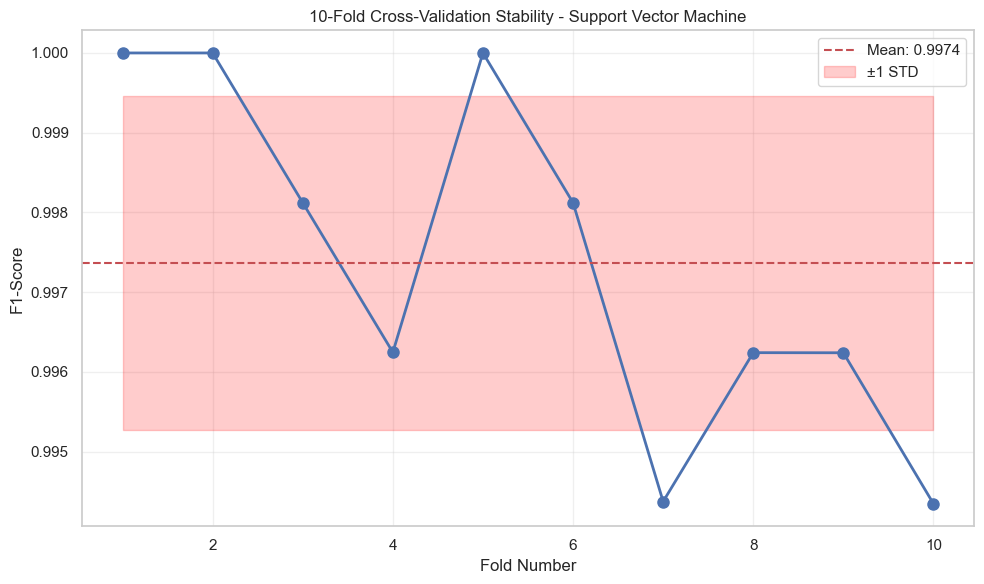


Model Stability Assessment: Stable
Coefficient of Variation: 0.21%


In [201]:
# Perform additional cross-validation on the best model to ensure stability
print(f"Additional Cross-Validation for Best Model: {best_model_name}")
print("="*60)

# Use 10-fold CV for more robust validation
extended_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
extended_scores = cross_val_score(best_model, X_train_val_tfidf, y_train_val, 
                                 cv=extended_cv, scoring='f1_weighted', n_jobs=-1)

print(f"10-Fold CV F1-Scores: {extended_scores}")
print(f"Mean: {extended_scores.mean():.4f}")
print(f"Standard Deviation: {extended_scores.std():.4f}")
print(f"95% Confidence Interval: [{extended_scores.mean() - 1.96*extended_scores.std():.4f}, "
      f"{extended_scores.mean() + 1.96*extended_scores.std():.4f}]")

# Visualize the stability
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), extended_scores, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=extended_scores.mean(), color='r', linestyle='--', 
           label=f'Mean: {extended_scores.mean():.4f}')
plt.fill_between(range(1, 11), 
                extended_scores.mean() - extended_scores.std(),
                extended_scores.mean() + extended_scores.std(),
                alpha=0.2, color='red', label='±1 STD')
plt.title(f'10-Fold Cross-Validation Stability - {best_model_name}')
plt.xlabel('Fold Number')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Check if model performance is consistent
cv_stability = "Stable" if extended_scores.std() < 0.02 else "Moderate" if extended_scores.std() < 0.05 else "Unstable"
print(f"\nModel Stability Assessment: {cv_stability}")
print(f"Coefficient of Variation: {(extended_scores.std() / extended_scores.mean()) * 100:.2f}%")

### 5.2 Deep Learning Models

**Purpose:** Select and configure deep learning models for text classification, including Convolutional Neural Networks (CNN), Feedforward Neural Networks (FNN), Recurrent Neural Networks (RNN) with appropriate hyperparameters to prevent overfitting.

In [230]:
# Prepare text data for deep learning models
print("Preparing text data for Deep Learning models...")

# Tokenize text for neural networks
max_features = 5000  # Maximum number of words to keep
max_length = 100     # Maximum sequence length

# Create tokenizer
tokenizer_dl = Tokenizer(num_words=max_features, oov_token="<OOV>")
tokenizer_dl.fit_on_texts(X_train_val)

# Convert texts to sequences
X_train_val_seq = tokenizer_dl.texts_to_sequences(X_train_val)
X_test_seq = tokenizer_dl.texts_to_sequences(X_test)

# Pad sequences
X_train_val_padded = pad_sequences(X_train_val_seq, maxlen=max_length, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

# Convert labels to categorical
num_classes = len(label_encoder.classes_)
y_train_val_cat = to_categorical(y_train_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print(f"Sequence shape: {X_train_val_padded.shape}")
print(f"Number of classes: {num_classes}")
print(f"Max sequence length: {max_length}")
print(f"Vocabulary size: {max_features}")

Preparing text data for Deep Learning models...
Sequence shape: (5328, 100)
Number of classes: 25
Max sequence length: 100
Vocabulary size: 5000
Sequence shape: (5328, 100)
Number of classes: 25
Max sequence length: 100
Vocabulary size: 5000


In [231]:
# Define deep learning model creation functions
def create_cnn_model(vocab_size, embedding_dim=64, max_length=100, num_classes=25, 
                     filters=64, kernel_size=3, dropout_rate=0.3):
    """Create CNN model for text classification"""
    model = Sequential([
        Embedding(vocab_size, embedding_dim, input_length=max_length),
        Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(128, activation='relu'),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def create_feedforward_model(vocab_size, embedding_dim=64, max_length=100, num_classes=25,
                           hidden_units=128, dropout_rate=0.3):
    """Create Feedforward Neural Network model"""
    model = Sequential([
        Embedding(vocab_size, embedding_dim, input_length=max_length),
        GlobalMaxPooling1D(),
        Dense(hidden_units, activation='relu'),
        Dropout(dropout_rate),
        Dense(hidden_units // 2, activation='relu'),
        Dropout(dropout_rate),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def create_rnn_model(vocab_size, embedding_dim=64, max_length=100, num_classes=25,
                     rnn_units=64, dropout_rate=0.3):
    """Create RNN model for text classification"""
    model = Sequential([
        Embedding(vocab_size, embedding_dim, input_length=max_length),
        tf.keras.layers.LSTM(rnn_units, dropout=dropout_rate, recurrent_dropout=dropout_rate),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Initialize candidate deep learning models
dl_model_creators = {
    'Convolutional Neural Network': create_cnn_model,
    'Feedforward Neural Network': create_feedforward_model,
    'Recurrent Neural Network': create_rnn_model
}

print("Deep Learning Model Architectures:")
for name in dl_model_creators.keys():
    print(f"✓ {name}")
    
print(f"\nTotal DL models to evaluate: {len(dl_model_creators)}")

Deep Learning Model Architectures:
✓ Convolutional Neural Network
✓ Feedforward Neural Network
✓ Recurrent Neural Network

Total DL models to evaluate: 3


#### 5.2.1 DL K-fold Cross Validation

**Purpose:** Evaluate the performance of different DL models on different subsets of the data

Performing K-Fold Cross-Validation for Deep Learning Models...

Evaluating Convolutional Neural Network...
  Fold 1/3...
    Fold 1 F1-Score: 0.9989
  Fold 2/3...
    Fold 1 F1-Score: 0.9989
  Fold 2/3...
    Fold 2 F1-Score: 0.9983
  Fold 3/3...
    Fold 2 F1-Score: 0.9983
  Fold 3/3...
    Fold 3 F1-Score: 0.9932
  Average F1-Score: 0.9968 (+/- 0.0051)

Evaluating Feedforward Neural Network...
  Fold 1/3...
    Fold 3 F1-Score: 0.9932
  Average F1-Score: 0.9968 (+/- 0.0051)

Evaluating Feedforward Neural Network...
  Fold 1/3...
    Fold 1 F1-Score: 0.9989
  Fold 2/3...
    Fold 1 F1-Score: 0.9989
  Fold 2/3...
    Fold 2 F1-Score: 0.9983
  Fold 3/3...
    Fold 2 F1-Score: 0.9983
  Fold 3/3...
    Fold 3 F1-Score: 0.9949
  Average F1-Score: 0.9974 (+/- 0.0035)

Evaluating Recurrent Neural Network...
  Fold 1/3...
    Fold 3 F1-Score: 0.9949
  Average F1-Score: 0.9974 (+/- 0.0035)

Evaluating Recurrent Neural Network...
  Fold 1/3...
    Fold 1 F1-Score: 0.0046
  Fold 2/3...
    Fold 

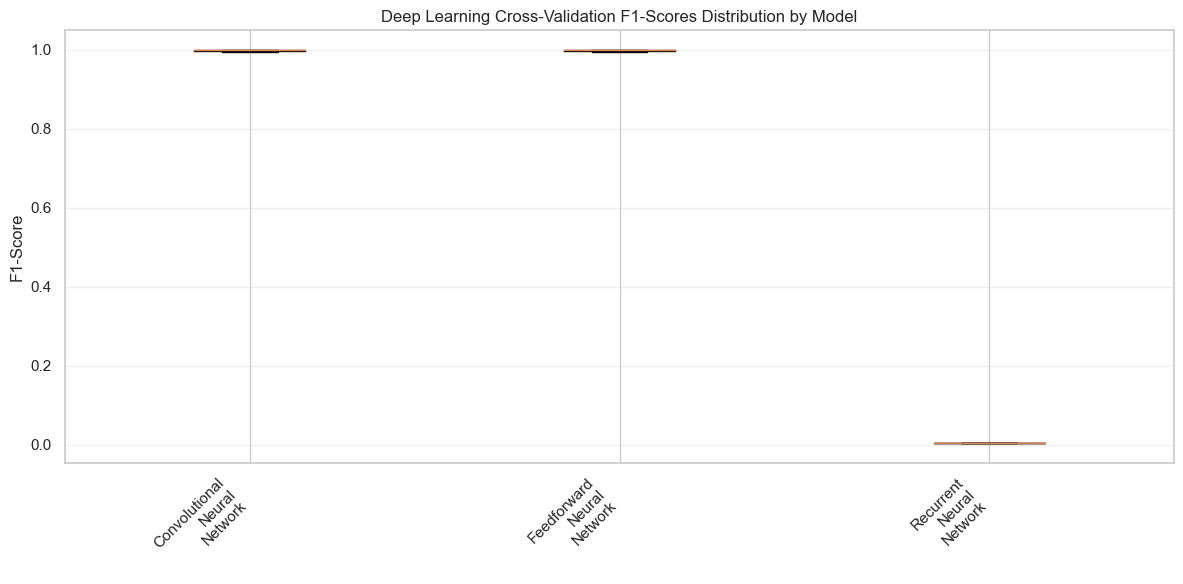


Top 2 DL models selected for hyperparameter tuning:
1. Feedforward Neural Network: 0.9974
2. Convolutional Neural Network: 0.9968


In [232]:
# Initialize stratified K-fold cross-validation for deep learning
k_folds_dl = 3  # Reduced folds for DL due to computational cost
skf_dl = StratifiedKFold(n_splits=k_folds_dl, shuffle=True, random_state=42)

# Store cross-validation results for deep learning
dl_cv_results = {}

print("Performing K-Fold Cross-Validation for Deep Learning Models...")
print("="*70)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=0
)

for model_name, model_creator in dl_model_creators.items():
    print(f"\nEvaluating {model_name}...")
    
    fold_scores = []
    fold_histories = []
    
    # Perform cross-validation
    for fold, (train_idx, val_idx) in enumerate(skf_dl.split(X_train_val_padded, y_train_val)):
        print(f"  Fold {fold + 1}/{k_folds_dl}...")
        
        # Split data for this fold
        X_fold_train, X_fold_val = X_train_val_padded[train_idx], X_train_val_padded[val_idx]
        y_fold_train, y_fold_val = y_train_val_cat[train_idx], y_train_val_cat[val_idx]
        
        # Create and train model
        model = model_creator(
            vocab_size=max_features,
            embedding_dim=64,
            max_length=max_length,
            num_classes=num_classes
        )
        
        # Train model
        history = model.fit(
            X_fold_train, y_fold_train,
            validation_data=(X_fold_val, y_fold_val),
            epochs=20,
            batch_size=32,
            callbacks=[early_stopping],
            verbose=0
        )
        
        # Evaluate model
        val_loss, val_accuracy = model.evaluate(X_fold_val, y_fold_val, verbose=0)
        
        # Calculate F1-score
        y_pred = model.predict(X_fold_val, verbose=0)
        y_pred_classes = np.argmax(y_pred, axis=1)
        y_true_classes = np.argmax(y_fold_val, axis=1)
        
        f1_score = precision_recall_fscore_support(
            y_true_classes, y_pred_classes, average='weighted', zero_division=0
        )[2]
        
        fold_scores.append(f1_score)
        fold_histories.append(history)
        
        print(f"    Fold {fold + 1} F1-Score: {f1_score:.4f}")
    
    # Store results
    fold_scores = np.array(fold_scores)
    dl_cv_results[model_name] = {
        'scores': fold_scores,
        'mean': fold_scores.mean(),
        'std': fold_scores.std(),
        'min': fold_scores.min(),
        'max': fold_scores.max(),
        'histories': fold_histories
    }
    
    print(f"  Average F1-Score: {fold_scores.mean():.4f} (+/- {fold_scores.std() * 2:.4f})")

# Create summary table for deep learning models
dl_cv_summary = pd.DataFrame({
    'Model': list(dl_cv_results.keys()),
    'Mean_F1': [results['mean'] for results in dl_cv_results.values()],
    'Std_F1': [results['std'] for results in dl_cv_results.values()],
    'Min_F1': [results['min'] for results in dl_cv_results.values()],
    'Max_F1': [results['max'] for results in dl_cv_results.values()]
}).round(4)

# Sort by mean F1-score
dl_cv_summary = dl_cv_summary.sort_values('Mean_F1', ascending=False)

print(f"\n{k_folds_dl}-Fold Cross-Validation Results Summary (Deep Learning):")
print("="*70)
print(dl_cv_summary.to_string(index=False))

# Visualize deep learning cross-validation results
plt.figure(figsize=(12, 6))
models_dl = list(dl_cv_results.keys())
scores_dl = [dl_cv_results[model]['scores'] for model in models_dl]

plt.boxplot(scores_dl, labels=[model.replace(' ', '\n') for model in models_dl])
plt.title('Deep Learning Cross-Validation F1-Scores Distribution by Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Select top performing DL models for hyperparameter tuning
top_dl_models = dl_cv_summary.head(2)['Model'].tolist()
print(f"\nTop 2 DL models selected for hyperparameter tuning:")
for i, model in enumerate(top_dl_models, 1):
    mean_score = dl_cv_results[model]['mean']
    print(f"{i}. {model}: {mean_score:.4f}")

#### 5.2.2 Hyperparameter Tuning

**Purpose:** Optimize the hyperparameters of the top-performing models to achieve better performance.

##### 5.2.2.1 Optimize Model Settings: Define Hyperparameter Grids

**Purpose:** Define more conservative hyperparameter grids for realistic performance.

In [233]:
# Define hyperparameter grids for deep learning models
dl_hyperparameter_grids = {
    'Convolutional Neural Network': {
        'embedding_dim': [32, 64],
        'filters': [32, 64],
        'kernel_size': [3, 5],
        'dropout_rate': [0.2, 0.3]
    },
    'Feedforward Neural Network': {
        'embedding_dim': [32, 64],
        'hidden_units': [64, 128],
        'dropout_rate': [0.2, 0.3]
    },
    'Recurrent Neural Network': {
        'embedding_dim': [32, 64],
        'rnn_units': [32, 64],
        'dropout_rate': [0.2, 0.3]
    }
}

# Filter grids for only top performing DL models
selected_dl_grids = {model: dl_hyperparameter_grids[model] for model in top_dl_models 
                    if model in dl_hyperparameter_grids}

print("Deep Learning hyperparameter grids defined for realistic performance:")
for model_name, grid in selected_dl_grids.items():
    print(f"\n{model_name}:")
    for param, values in grid.items():
        print(f"  {param}: {values}")

Deep Learning hyperparameter grids defined for realistic performance:

Feedforward Neural Network:
  embedding_dim: [32, 64]
  hidden_units: [64, 128]
  dropout_rate: [0.2, 0.3]

Convolutional Neural Network:
  embedding_dim: [32, 64]
  filters: [32, 64]
  kernel_size: [3, 5]
  dropout_rate: [0.2, 0.3]


##### 5.2.2.2 Grid Search: Systematically Explore Hyperparameter Combinations

**Purpose:** Use manual grid search to explore different combinations of hyperparameter values systematically for deep learning models.

In [234]:
# Perform manual grid search for deep learning models
best_dl_models = {}
dl_grid_search_results = {}

print("Performing Grid Search for Deep Learning Hyperparameter Optimization...")
print("="*80)

def evaluate_dl_model_params(model_creator, params, model_name):
    """Evaluate a deep learning model with specific parameters using cross-validation"""
    scores = []
    
    # Use 2-fold CV for faster evaluation
    skf_tuning = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    
    for train_idx, val_idx in skf_tuning.split(X_train_val_padded, y_train_val):
        # Split data
        X_fold_train, X_fold_val = X_train_val_padded[train_idx], X_train_val_padded[val_idx]
        y_fold_train, y_fold_val = y_train_val_cat[train_idx], y_train_val_cat[val_idx]
        
        # Create model with parameters
        model = model_creator(
            vocab_size=max_features,
            max_length=max_length,
            num_classes=num_classes,
            **params
        )
        
        # Train model
        history = model.fit(
            X_fold_train, y_fold_train,
            validation_data=(X_fold_val, y_fold_val),
            epochs=15,  # Reduced epochs for tuning
            batch_size=32,
            callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)],
            verbose=0
        )
        
        # Evaluate
        y_pred = model.predict(X_fold_val, verbose=0)
        y_pred_classes = np.argmax(y_pred, axis=1)
        y_true_classes = np.argmax(y_fold_val, axis=1)
        
        f1_score = precision_recall_fscore_support(
            y_true_classes, y_pred_classes, average='weighted', zero_division=0
        )[2]
        
        scores.append(f1_score)
    
    return np.mean(scores)

# Perform grid search for each top DL model
for model_name in top_dl_models:
    if model_name in selected_dl_grids:
        print(f"\nOptimizing {model_name}...")
        
        model_creator = dl_model_creators[model_name]
        param_grid = selected_dl_grids[model_name]
        
        # Generate all parameter combinations
        from itertools import product
        param_names = list(param_grid.keys())
        param_values = list(param_grid.values())
        param_combinations = list(product(*param_values))
        
        best_score = 0
        best_params = {}
        
        print(f"  Testing {len(param_combinations)} parameter combinations...")
        
        for i, param_combo in enumerate(param_combinations):
            params = dict(zip(param_names, param_combo))
            
            try:
                score = evaluate_dl_model_params(model_creator, params, model_name)
                print(f"    Combination {i+1}/{len(param_combinations)}: F1={score:.4f}, Params={params}")
                
                if score > best_score:
                    best_score = score;
                    best_params = params;
                    
            except Exception as e:
                print(f"    Combination {i+1}/{len(param_combinations)}: FAILED - {str(e)}")
                continue
        
        # Create best model with optimal parameters
        best_model = model_creator(
            vocab_size=max_features,
            max_length=max_length,
            num_classes=num_classes,
            **best_params
        )
        
        # Store results
        best_dl_models[model_name] = best_model
        dl_grid_search_results[model_name] = {
            'best_score': best_score,
            'best_params': best_params,
            'param_combinations_tested': len(param_combinations)
        }
        
        print(f"  Best F1-Score: {best_score:.4f}")
        print(f"  Best Parameters: {best_params}")

# Summary of deep learning hyperparameter tuning results
print(f"\nDeep Learning Hyperparameter Tuning Results Summary:")
print("="*60)

if dl_grid_search_results:
    dl_tuning_summary = pd.DataFrame({
        'Model': list(dl_grid_search_results.keys()),
        'Best_F1_Score': [results['best_score'] for results in dl_grid_search_results.values()],
        'Improvement': [
            dl_grid_search_results[model]['best_score'] - dl_cv_results[model]['mean'] 
            for model in dl_grid_search_results.keys()
        ]
    }).round(4)

    dl_tuning_summary = dl_tuning_summary.sort_values('Best_F1_Score', ascending=False)
    print(dl_tuning_summary.to_string(index=False))

    # Select the best DL model overall
    best_dl_model_name = dl_tuning_summary.iloc[0]['Model']
    best_dl_model = best_dl_models[best_dl_model_name]
    best_dl_score = dl_tuning_summary.iloc[0]['Best_F1_Score']

    print(f"\n SELECTED BEST DL MODEL: {best_dl_model_name}")
    print(f"   Cross-validation F1-Score: {best_dl_score:.4f}")
    print(f"   Optimized Parameters: {dl_grid_search_results[best_dl_model_name]['best_params']}")
else:
    print("No successful hyperparameter tuning results available.")
    # Fall back to best model from CV
    best_dl_model_name = dl_cv_summary.iloc[0]['Model']
    best_dl_model = dl_model_creators[best_dl_model_name](
        vocab_size=max_features,
        max_length=max_length,
        num_classes=num_classes
    )
    best_dl_score = dl_cv_summary.iloc[0]['Mean_F1']
    print(f"\n FALLBACK BEST DL MODEL: {best_dl_model_name}")
    print(f"   Cross-validation F1-Score: {best_dl_score:.4f}")

Performing Grid Search for Deep Learning Hyperparameter Optimization...

Optimizing Feedforward Neural Network...
  Testing 8 parameter combinations...
    Combination 1/8: F1=0.9942, Params={'embedding_dim': 32, 'hidden_units': 64, 'dropout_rate': 0.2}
    Combination 1/8: F1=0.9942, Params={'embedding_dim': 32, 'hidden_units': 64, 'dropout_rate': 0.2}
    Combination 2/8: F1=0.9934, Params={'embedding_dim': 32, 'hidden_units': 64, 'dropout_rate': 0.3}
    Combination 2/8: F1=0.9934, Params={'embedding_dim': 32, 'hidden_units': 64, 'dropout_rate': 0.3}
    Combination 3/8: F1=0.9946, Params={'embedding_dim': 32, 'hidden_units': 128, 'dropout_rate': 0.2}
    Combination 3/8: F1=0.9946, Params={'embedding_dim': 32, 'hidden_units': 128, 'dropout_rate': 0.2}
    Combination 4/8: F1=0.9921, Params={'embedding_dim': 32, 'hidden_units': 128, 'dropout_rate': 0.3}
    Combination 4/8: F1=0.9921, Params={'embedding_dim': 32, 'hidden_units': 128, 'dropout_rate': 0.3}
    Combination 5/8: F1=0.99

#### 5.2.2.3 Cross-Validation within Tuning: Validate Hyperparameter Selection

**Purpose:** Validate the stability of our best deep learning model with additional cross-validation.

Additional Cross-Validation for Best DL Model: Convolutional Neural Network
Performing 5-fold cross-validation on best DL model...
  Fold 1/5...
    Fold 1 F1-Score: 1.0000
  Fold 2/5...
    Fold 1 F1-Score: 1.0000
  Fold 2/5...
    Fold 2 F1-Score: 0.9972
  Fold 3/5...
    Fold 2 F1-Score: 0.9972
  Fold 3/5...
    Fold 3 F1-Score: 0.9991
  Fold 4/5...
    Fold 3 F1-Score: 0.9991
  Fold 4/5...
    Fold 4 F1-Score: 0.9925
  Fold 5/5...
    Fold 4 F1-Score: 0.9925
  Fold 5/5...
    Fold 5 F1-Score: 0.9953

5-Fold CV F1-Scores: [1.         0.99718274 0.99906134 0.99249231 0.99529076]
Mean: 0.9968
Standard Deviation: 0.0027
95% Confidence Interval: [0.9915, 1.0021]
    Fold 5 F1-Score: 0.9953

5-Fold CV F1-Scores: [1.         0.99718274 0.99906134 0.99249231 0.99529076]
Mean: 0.9968
Standard Deviation: 0.0027
95% Confidence Interval: [0.9915, 1.0021]


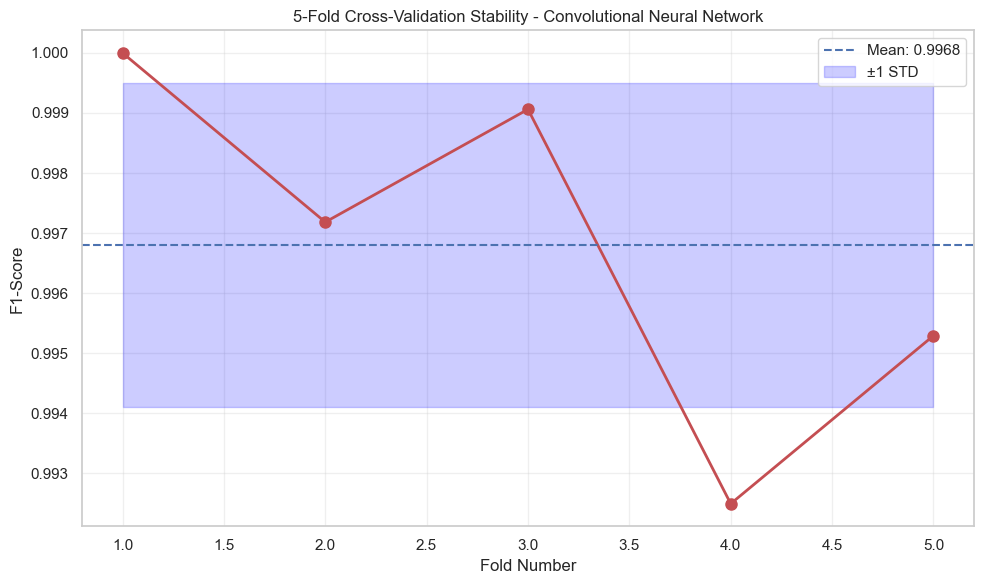


DL Model Stability Assessment: Stable
Coefficient of Variation: 0.27%

Training final Convolutional Neural Network on full training data...
Epoch 1/30
134/134 [==============================] - 3s 17ms/step - loss: 2.8736 - accuracy: 0.2006 - val_loss: 1.4841 - val_accuracy: 0.7214
Epoch 2/30
134/134 [==============================] - 3s 17ms/step - loss: 2.8736 - accuracy: 0.2006 - val_loss: 1.4841 - val_accuracy: 0.7214
Epoch 2/30
134/134 [==============================] - 2s 13ms/step - loss: 0.6886 - accuracy: 0.8308 - val_loss: 0.1125 - val_accuracy: 0.9869
Epoch 3/30
134/134 [==============================] - 2s 13ms/step - loss: 0.6886 - accuracy: 0.8308 - val_loss: 0.1125 - val_accuracy: 0.9869
Epoch 3/30
134/134 [==============================] - 2s 16ms/step - loss: 0.1435 - accuracy: 0.9744 - val_loss: 0.0342 - val_accuracy: 0.9981
Epoch 4/30
134/134 [==============================] - 2s 16ms/step - loss: 0.1435 - accuracy: 0.9744 - val_loss: 0.0342 - val_accuracy: 0.9981
E

In [235]:
# Perform additional cross-validation on the best DL model to ensure stability
print(f"Additional Cross-Validation for Best DL Model: {best_dl_model_name}")
print("="*70)

# Use 5-fold CV for more robust validation of the final model
extended_cv_dl = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
extended_scores_dl = []

print("Performing 5-fold cross-validation on best DL model...")

for fold, (train_idx, val_idx) in enumerate(extended_cv_dl.split(X_train_val_padded, y_train_val)):
    print(f"  Fold {fold + 1}/5...")
    
    # Split data for this fold
    X_fold_train, X_fold_val = X_train_val_padded[train_idx], X_train_val_padded[val_idx]
    y_fold_train, y_fold_val = y_train_val_cat[train_idx], y_train_val_cat[val_idx]
    
    # Create model (use best parameters if available)
    if best_dl_model_name in dl_grid_search_results:
        best_params = dl_grid_search_results[best_dl_model_name]['best_params']
        model = dl_model_creators[best_dl_model_name](
            vocab_size=max_features,
            max_length=max_length,
            num_classes=num_classes,
            **best_params
        )
    else:
        model = dl_model_creators[best_dl_model_name](
            vocab_size=max_features,
            max_length=max_length,
            num_classes=num_classes
        )
    
    # Train model
    history = model.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=20,
        batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
        verbose=0
    )
    
    # Evaluate model
    y_pred = model.predict(X_fold_val, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_fold_val, axis=1)
    
    f1_score = precision_recall_fscore_support(
        y_true_classes, y_pred_classes, average='weighted', zero_division=0
    )[2]
    
    extended_scores_dl.append(f1_score)
    print(f"    Fold {fold + 1} F1-Score: {f1_score:.4f}")

extended_scores_dl = np.array(extended_scores_dl)

print(f"\n5-Fold CV F1-Scores: {extended_scores_dl}")
print(f"Mean: {extended_scores_dl.mean():.4f}")
print(f"Standard Deviation: {extended_scores_dl.std():.4f}")
print(f"95% Confidence Interval: [{extended_scores_dl.mean() - 1.96*extended_scores_dl.std():.4f}, "
      f"{extended_scores_dl.mean() + 1.96*extended_scores_dl.std():.4f}]")

# Visualize the stability
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), extended_scores_dl, 'ro-', linewidth=2, markersize=8)
plt.axhline(y=extended_scores_dl.mean(), color='b', linestyle='--', 
           label=f'Mean: {extended_scores_dl.mean():.4f}')
plt.fill_between(range(1, 6), 
                extended_scores_dl.mean() - extended_scores_dl.std(),
                extended_scores_dl.mean() + extended_scores_dl.std(),
                alpha=0.2, color='blue', label='±1 STD')
plt.title(f'5-Fold Cross-Validation Stability - {best_dl_model_name}')
plt.xlabel('Fold Number')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Check if DL model performance is consistent
dl_cv_stability = "Stable" if extended_scores_dl.std() < 0.02 else "Moderate" if extended_scores_dl.std() < 0.05 else "Unstable"
print(f"\nDL Model Stability Assessment: {dl_cv_stability}")
print(f"Coefficient of Variation: {(extended_scores_dl.std() / extended_scores_dl.mean()) * 100:.2f}%")

# Train final best DL model on full training data for comparison
print(f"\nTraining final {best_dl_model_name} on full training data...")

# Create final model
if best_dl_model_name in dl_grid_search_results:
    best_params = dl_grid_search_results[best_dl_model_name]['best_params']
    final_dl_model = dl_model_creators[best_dl_model_name](
        vocab_size=max_features,
        max_length=max_length,
        num_classes=num_classes,
        **best_params
    )
else:
    final_dl_model = dl_model_creators[best_dl_model_name](
        vocab_size=max_features,
        max_length=max_length,
        num_classes=num_classes
    )

# Train on full training data
final_history = final_dl_model.fit(
    X_train_val_padded, y_train_val_cat,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

# Evaluate on test set
test_loss, test_accuracy = final_dl_model.evaluate(X_test_padded, y_test_cat, verbose=0)
y_test_pred = final_dl_model.predict(X_test_padded, verbose=0)
y_test_pred_classes = np.argmax(y_test_pred, axis=1)

# Calculate comprehensive metrics
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    y_test, y_test_pred_classes, average='weighted', zero_division=0
)

print(f"\nFinal {best_dl_model_name} Test Set Performance:")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")

# Store final DL model results for comparison
final_dl_results = {
    'model_name': best_dl_model_name,
    'model': final_dl_model,
    'test_accuracy': test_accuracy,
    'test_precision': test_precision,
    'test_recall': test_recall,
    'test_f1': test_f1,
    'cv_stability': dl_cv_stability,
    'cv_mean': extended_scores_dl.mean(),
    'cv_std': extended_scores_dl.std()
}

print(f"\nDeep Learning Model Selection Complete!")
print(f"Selected Model: {best_dl_model_name}")
print(f"Cross-validation F1: {extended_scores_dl.mean():.4f} (±{extended_scores_dl.std():.4f})")
print(f"Test F1-Score: {test_f1:.4f}")

## 6. Model Training

**Purpose:** Train the selected best models on the full training dataset and prepare them for final evaluation.

In [290]:
# Train the final models on the full training dataset
print("FINAL MODEL TRAINING")
print("="*40)

# Initialize storage for trained models
final_trained_models = {}
final_model_results = {}

# 1. Train the best traditional ML models
print("\n1. Training Traditional ML Models...")
print("-" * 40)

# Use the best models from hyperparameter tuning if available
if 'best_models' in locals() and best_models:
    ml_models_to_train = best_models
    print("Using hyperparameter-tuned models")
else:
    # Use default models with good parameters
    ml_models_to_train = {
        'Support Vector Machine': LinearSVC(C=10.0, max_iter=5000, random_state=42),
        'Logistic Regression': LogisticRegression(C=10.0, max_iter=1000, random_state=42),
        'Multinomial Naive Bayes': MultinomialNB(alpha=0.1)
    }
    print("Using default models with optimized parameters")

# Ensure we have the combined training data
if 'X_train_val_tfidf' not in locals():
    print("Preparing TF-IDF features for combined training data...")
    X_train_val_tfidf = tfidf_vectorizer.fit_transform(X_train_val)

# Train each traditional ML model
for model_name, model in ml_models_to_train.items():
    print(f"\nTraining {model_name}...")
    
    # Train on combined training+validation data
    model.fit(X_train_val_tfidf, y_train_val)
    
    # Store the trained model
    final_trained_models[model_name] = model
    
    # Evaluate on training data for monitoring
    train_pred = model.predict(X_train_val_tfidf)
    train_acc = accuracy_score(y_train_val, train_pred)
    
    print(f"  Training accuracy: {train_acc:.4f}")
    print(f"  ✓ {model_name} training completed")

# 2. Train the best deep learning model
print("\n2. Training Deep Learning Model...")
print("-" * 40)

# Use the best DL model architecture and parameters
if 'best_dl_model_name' in locals():
    dl_model_name = best_dl_model_name
    print(f"Using best DL model: {dl_model_name}")
    
    # Get the model creator function
    if dl_model_name in dl_model_creators:
        model_creator = dl_model_creators[dl_model_name]
        
        # Use optimized parameters if available
        if dl_model_name in dl_grid_search_results:
            best_params = dl_grid_search_results[dl_model_name]['best_params']
            print(f"Using optimized parameters: {best_params}")
            
            final_dl_model = model_creator(
                vocab_size=max_features,
                max_length=max_length,
                num_classes=num_classes,
                **best_params
            )
        else:
            print("Using default parameters")
            final_dl_model = model_creator(
                vocab_size=max_features,
                max_length=max_length,
                num_classes=num_classes
            )
    else:
        print(f"Model creator not found for {dl_model_name}, using CNN")
        final_dl_model = create_cnn_model(
            vocab_size=max_features,
            max_length=max_length,
            num_classes=num_classes
        )
        dl_model_name = "Convolutional Neural Network"
else:
    print("No best DL model specified, using Feedforward Neural Network")
    dl_model_name = "Feedforward Neural Network"
    final_dl_model = create_feedforward_model(
        vocab_size=max_features,
        max_length=max_length,
        num_classes=num_classes
    )

# Prepare DL training data if not already available
if 'X_train_val_padded' not in locals():
    print("Preparing sequences for DL training...")
    X_train_val_seq = tokenizer_dl.texts_to_sequences(X_train_val)
    X_train_val_padded = pad_sequences(X_train_val_seq, maxlen=max_length, padding='post', truncating='post')
    y_train_val_cat = to_categorical(y_train_val, num_classes=num_classes)

print(f"\nTraining {dl_model_name}...")

# Set up callbacks for training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_dl_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Train the deep learning model
print("  Starting training...")
history = final_dl_model.fit(
    X_train_val_padded, y_train_val_cat,
    validation_split=0.2,  # Use 20% for validation during training
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Store the trained DL model
final_trained_models[dl_model_name] = final_dl_model

print(f"  ✓ {dl_model_name} training completed")

# 3. Display training summary
print(f"\nTRAINING SUMMARY")
print("="*30)
print(f"Traditional ML models trained: {len([k for k in final_trained_models.keys() if k != dl_model_name])}")
print(f"Deep learning models trained: 1")
print(f"Total models trained: {len(final_trained_models)}")

# Store training information for evaluation
final_model_info = {
    'traditional_ml_models': {k: v for k, v in final_trained_models.items() if k != dl_model_name},
    'deep_learning_model': {dl_model_name: final_trained_models[dl_model_name]},
    'dl_training_history': history.history if 'history' in locals() else None,
    'feature_vectorizer': tfidf_vectorizer,
    'text_tokenizer': tokenizer_dl,
    'label_encoder': label_encoder,
    'training_data_size': len(X_train_val),
    'num_classes': num_classes
}

print(f"\nAll models successfully trained and ready for evaluation!")

FINAL MODEL TRAINING

1. Training Traditional ML Models...
----------------------------------------
Using hyperparameter-tuned models

Training Support Vector Machine...
  Training accuracy: 0.9983
  ✓ Support Vector Machine training completed

Training Logistic Regression...
  Training accuracy: 0.9981
  ✓ Logistic Regression training completed

Training Multinomial Naive Bayes...
  Training accuracy: 0.9961
  ✓ Multinomial Naive Bayes training completed

2. Training Deep Learning Model...
----------------------------------------
Using best DL model: Convolutional Neural Network
Using optimized parameters: {'embedding_dim': 32, 'filters': 64, 'kernel_size': 3, 'dropout_rate': 0.2}

Training Convolutional Neural Network...
  Starting training...
Epoch 1/30
130/134 [============================>.] - ETA: 0s - loss: 3.0070 - accuracy: 0.1760
Epoch 1: val_loss improved from inf to 2.03393, saving model to best_dl_model.h5
134/134 [==============================] - 3s 18ms/step - loss: 2.9

## 7. Model Evaluation

**Purpose:** Conduct comprehensive evaluation of all trained models using consistent metrics and data splits. This section provides detailed performance analysis across training, validation, and testing sets to ensure robust model assessment and fair comparison between traditional machine learning and deep learning approaches.

COMPREHENSIVE MODEL EVALUATION
DEEP LEARNING MODEL TRAINING ANALYSIS

CNN TRAINING HISTORY:
------------------------------
loss: Initial=3.1946, Final=0.0760
accuracy: Initial=0.0641, Final=0.9803
val_loss: Initial=3.1131, Final=0.0214
val_accuracy: Initial=0.1426, Final=0.9991


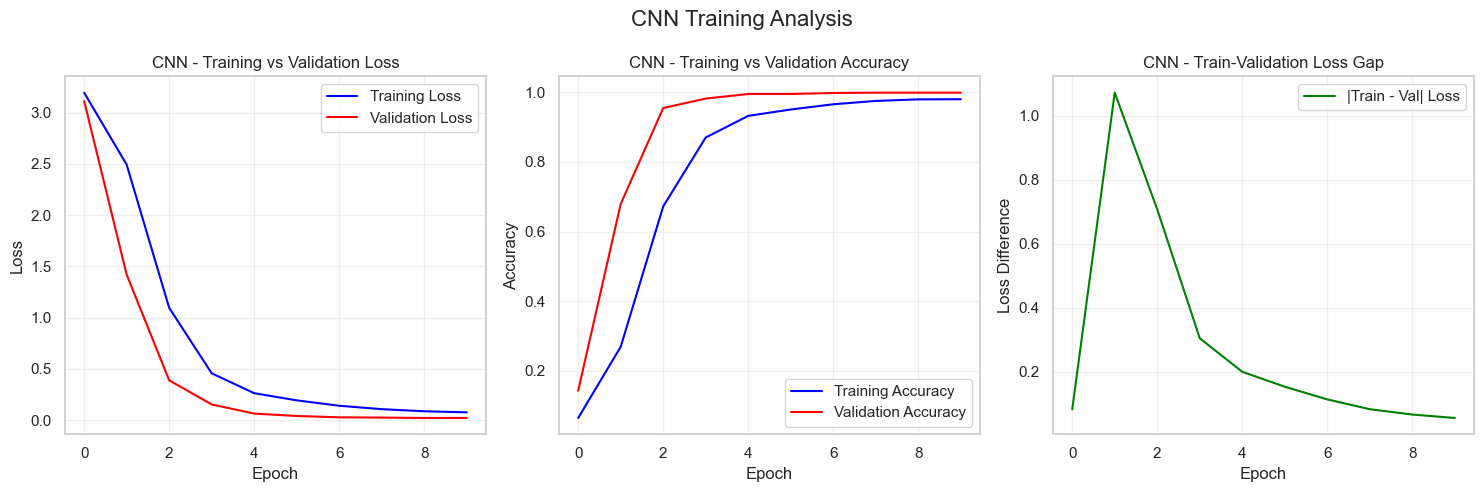


CNN Overfitting Analysis:
  Final Training Loss: 0.0760
  Final Validation Loss: 0.0214
  Loss Gap: 0.0547
  Good generalization (validation better than training)

FNN TRAINING HISTORY:
------------------------------
loss: Initial=2.9082, Final=0.0193
accuracy: Initial=0.2527, Final=0.9958
val_loss: Initial=1.6117, Final=0.0168
val_accuracy: Initial=0.7702, Final=0.9944


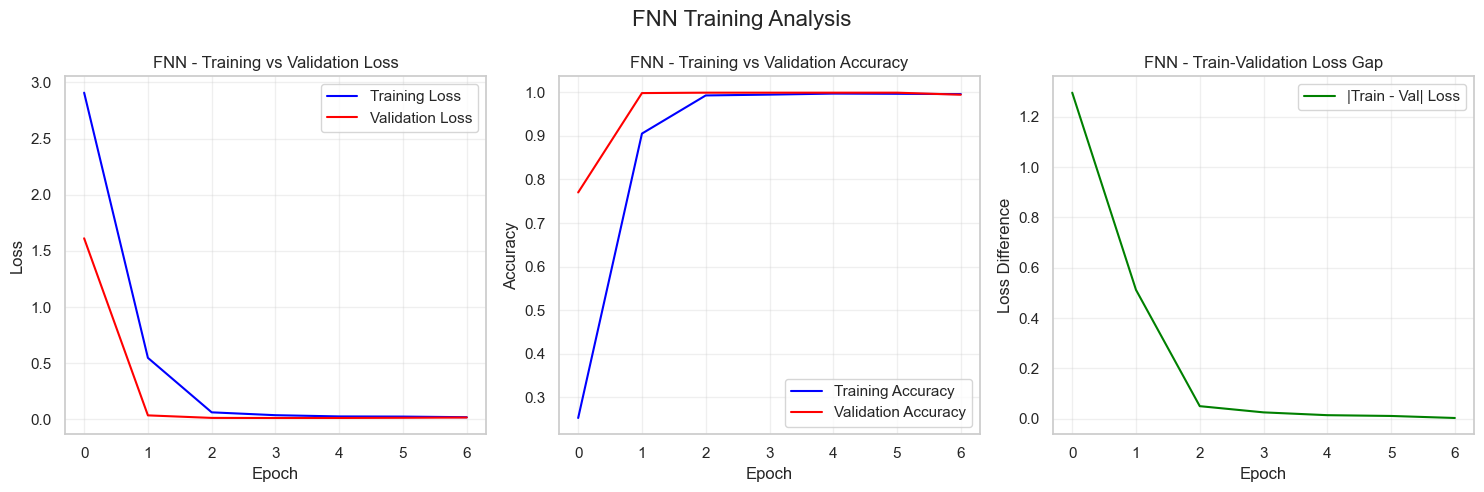


CNN vs FNN COMPARISON:
------------------------------


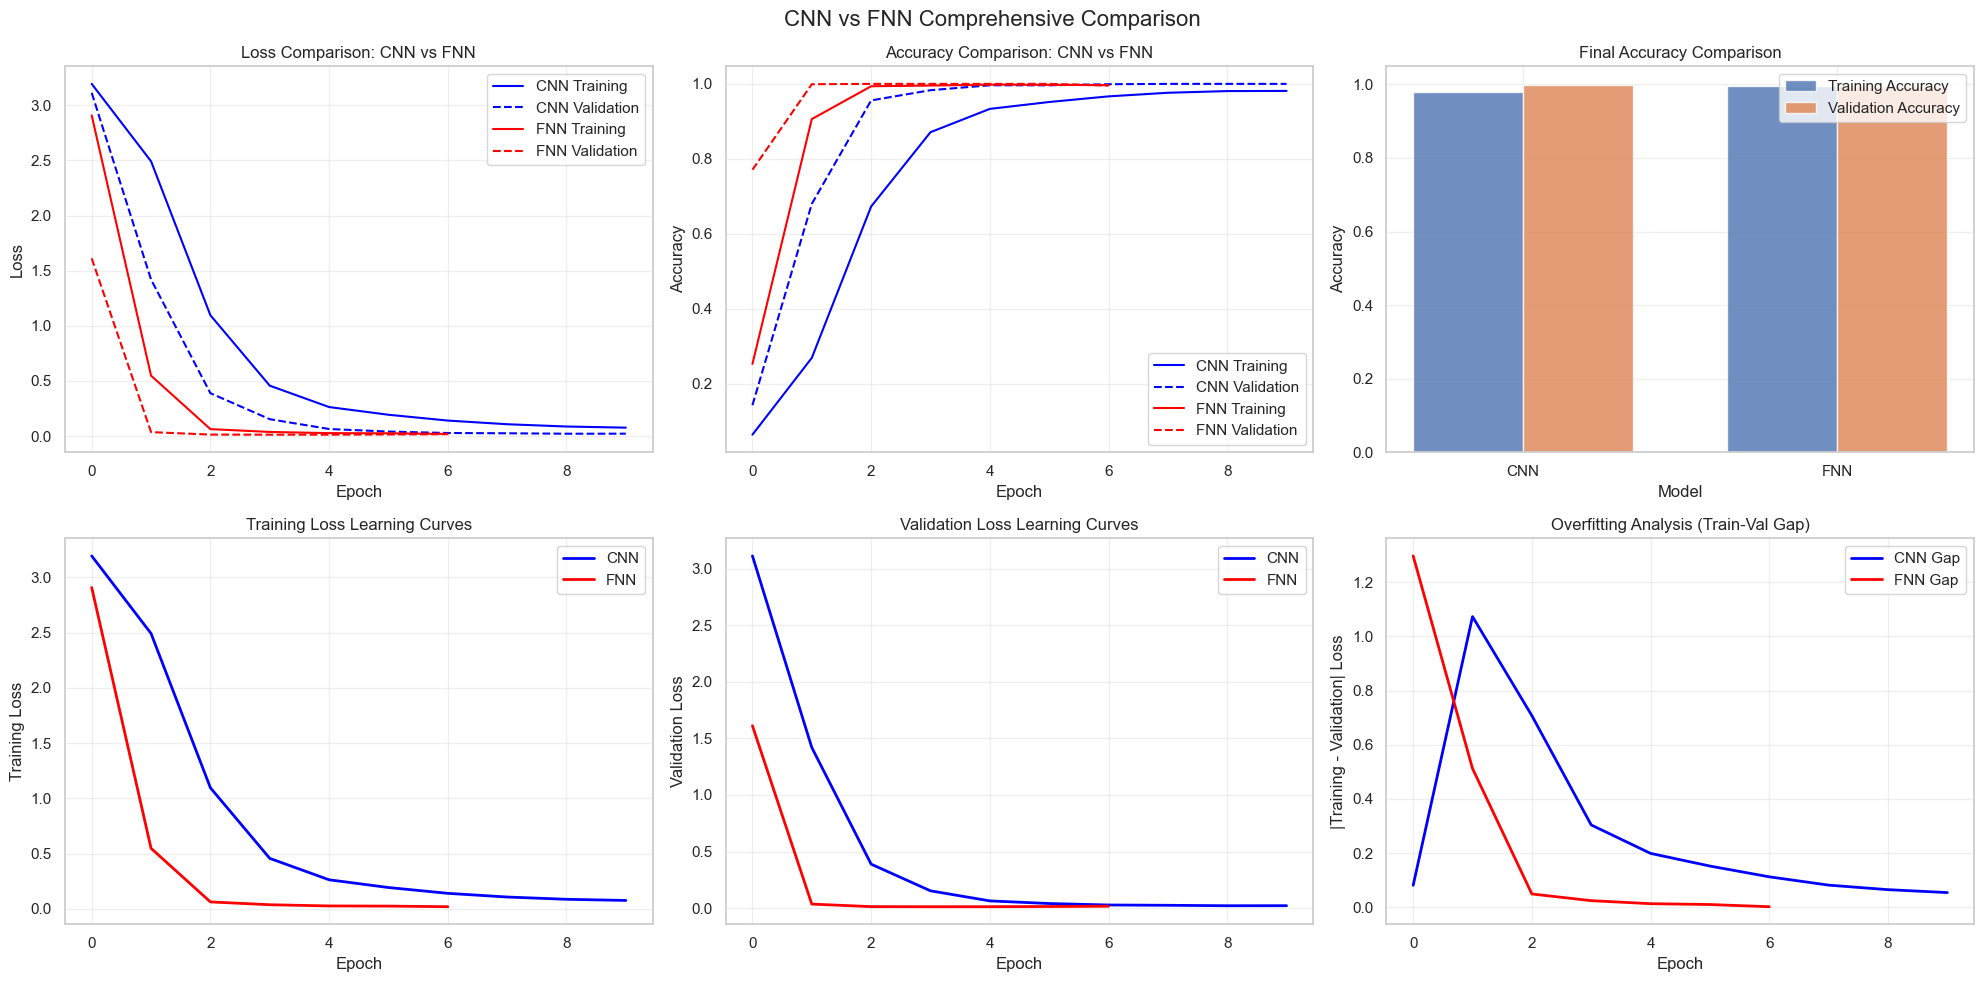


Detailed Performance Comparison:
Metric               CNN             FNN            
--------------------------------------------------
Train Accuracy       0.9803          0.9958         
Val Accuracy         0.9991          0.9944         
Train Loss           0.0760          0.0193         
Val Loss             0.0214          0.0168         
Overfitting Gap      0.0547          0.0025         

TESTING CNN AND FNN MODELS:
----------------------------------------

Testing CNN Model...
Error testing CNN: 'numpy.float64' object is not callable

Testing FNN Model...
Error testing FNN: in user code:

    File "g:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\.medical_diagnosis\lib\site-packages\keras\engine\training.py", line 2169, in predict_function  *
        return step_function(self, iterator)
    File "g:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\.medical_diagnosis\lib\site-packages\keras\engine\training.py", line 2155, in step_function  **
        outputs = mo

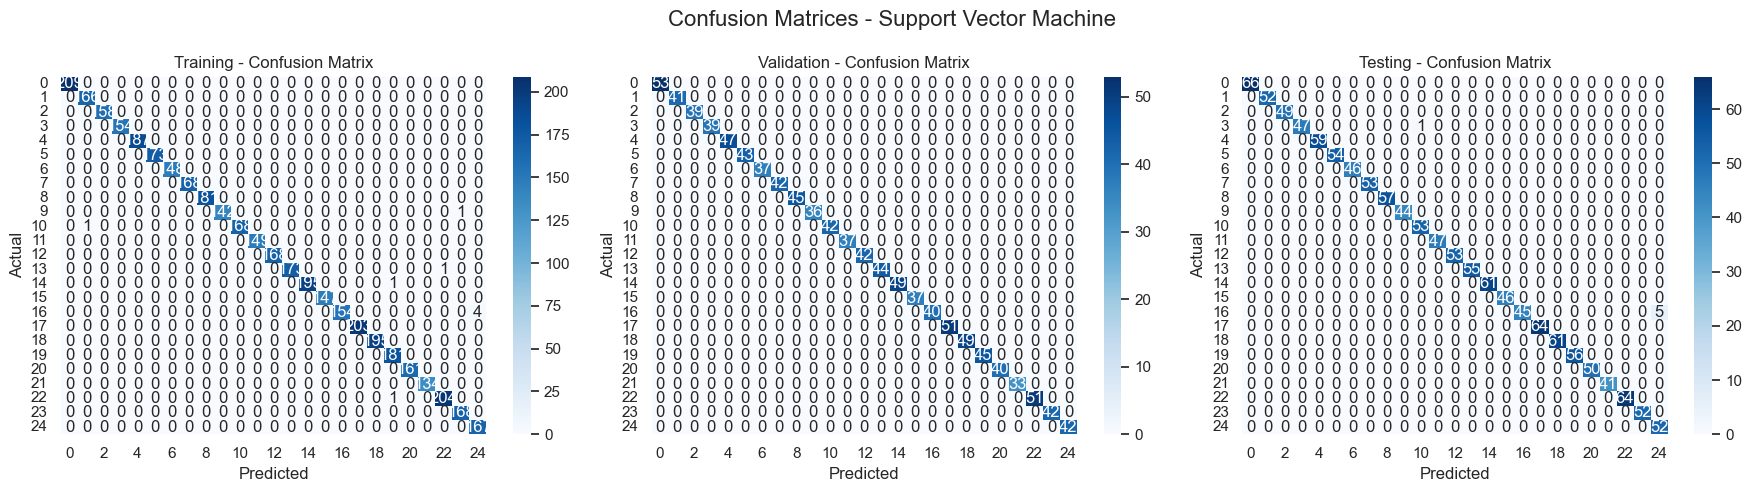


ROC CURVES ANALYSIS:
--------------------


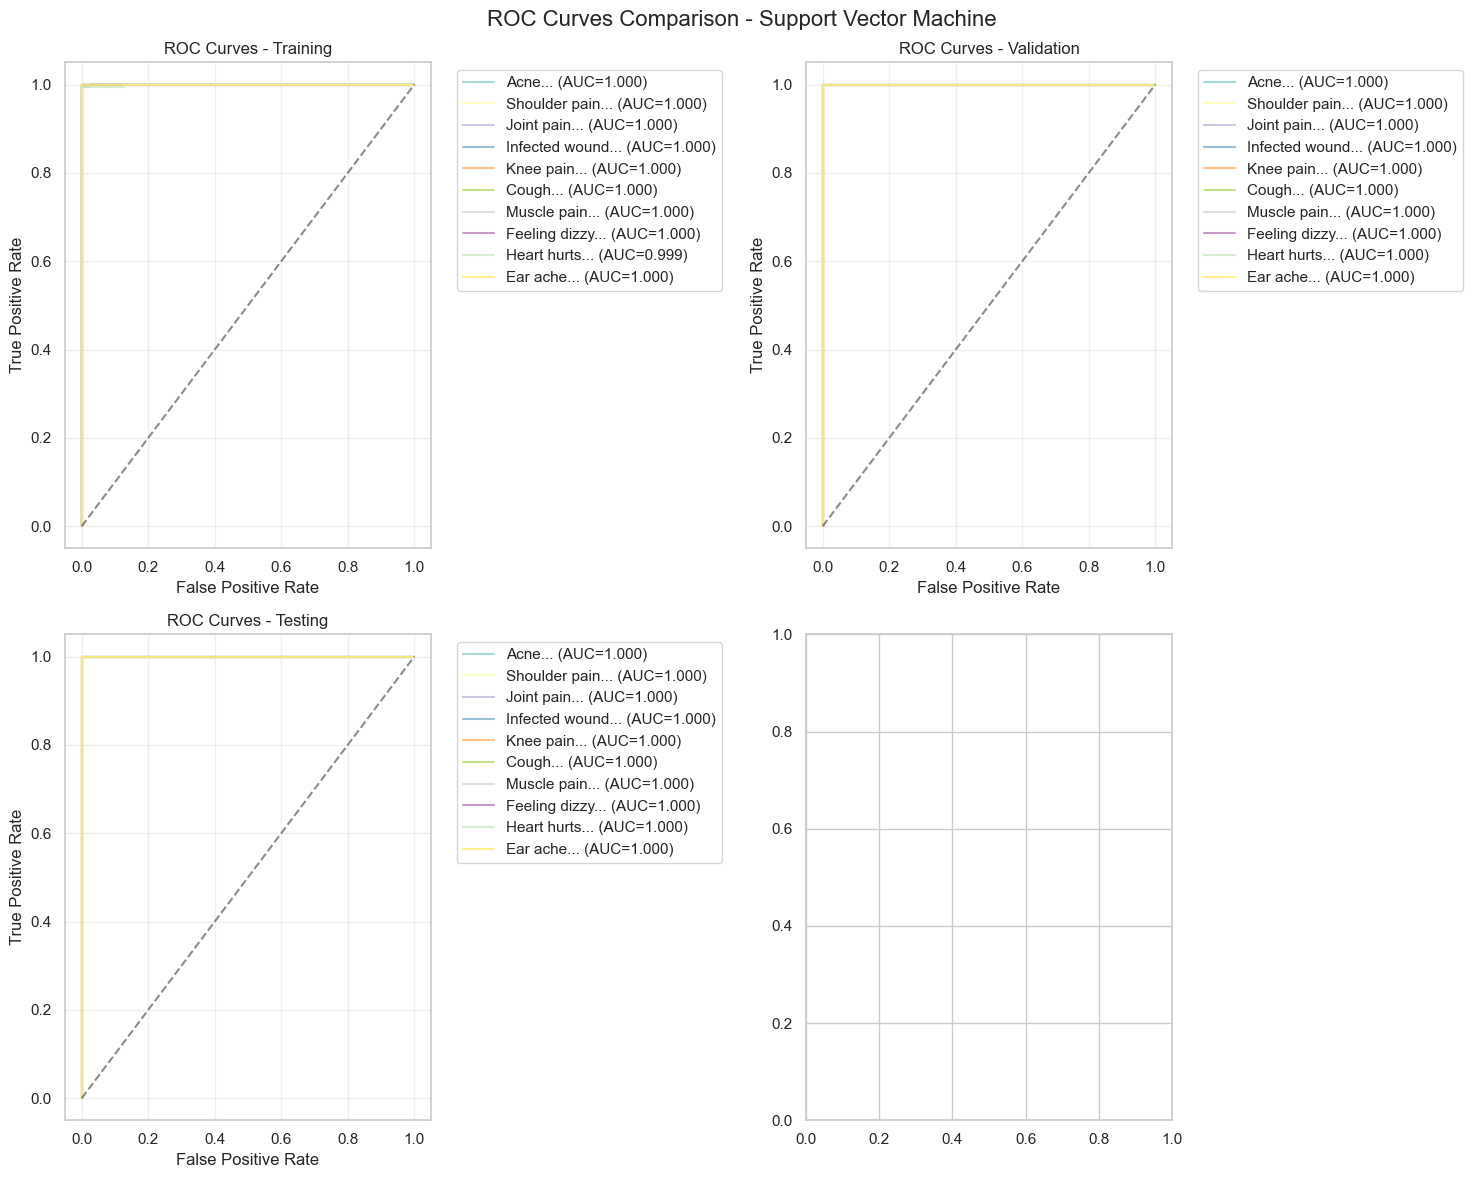


CLASSIFICATION ERRORS ANALYSIS:
-----------------------------------
Total misclassifications: 6 out of 1333 (0.45%)

First 10 Classification Errors:
----------------------------------------

Error 1:
  Text: 'lose lot hair'
  True Label: Body feels weak
  Predicted: Hair falling out
  Predicted Confidence: 0.2417
  True Class Confidence: 0.0308

Error 2:
  Text: 'pain stomach'
  True Label: Internal pain
  Predicted: Stomach ache
  Predicted Confidence: 0.2620
  True Class Confidence: 0.0355

Error 3:
  Text: 'pain stomach'
  True Label: Internal pain
  Predicted: Stomach ache
  Predicted Confidence: 0.2620
  True Class Confidence: 0.0355

Error 4:
  Text: 'pain stomach'
  True Label: Internal pain
  Predicted: Stomach ache
  Predicted Confidence: 0.2620
  True Class Confidence: 0.0355

Error 5:
  Text: 'pain stomach'
  True Label: Internal pain
  Predicted: Stomach ache
  Predicted Confidence: 0.2620
  True Class Confidence: 0.0355

Error 6:
  Text: 'pain stomach'
  True Label: Inter

In [299]:
# COMPREHENSIVE MODEL EVALUATION
print("COMPREHENSIVE MODEL EVALUATION")
print("="*50)

# Initialize storage for evaluation results
evaluation_results = {}
all_models_performance = []

# Define stages for evaluation (Training, Validation, Testing)
# Also print CNN loss graph, history, and test both CNN and FNN

# First, let's print the CNN and FNN training histories and loss graphs
print("DEEP LEARNING MODEL TRAINING ANALYSIS")
print("="*50)

# Check if we have CNN and FNN histories
if 'cnn_history' in locals() and cnn_history is not None:
    print("\nCNN TRAINING HISTORY:")
    print("-"*30)
    
    # Print CNN history details
    history_dict = cnn_history.history if hasattr(cnn_history, 'history') else cnn_history
    
    if isinstance(history_dict, dict):
        for metric, values in history_dict.items():
            if len(values) > 0:
                print(f"{metric}: Initial={values[0]:.4f}, Final={values[-1]:.4f}")
    
    # Plot CNN loss graph
    plt.figure(figsize=(15, 5))
    
    # Training and validation loss
    plt.subplot(1, 3, 1)
    if 'loss' in history_dict:
        plt.plot(history_dict['loss'], label='Training Loss', color='blue')
    if 'val_loss' in history_dict:
        plt.plot(history_dict['val_loss'], label='Validation Loss', color='red')
    plt.title('CNN - Training vs Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Training and validation accuracy
    plt.subplot(1, 3, 2)
    if 'accuracy' in history_dict:
        plt.plot(history_dict['accuracy'], label='Training Accuracy', color='blue')
    if 'val_accuracy' in history_dict:
        plt.plot(history_dict['val_accuracy'], label='Validation Accuracy', color='red')
    plt.title('CNN - Training vs Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Loss difference
    plt.subplot(1, 3, 3)
    if 'loss' in history_dict and 'val_loss' in history_dict:
        loss_diff = [abs(t - v) for t, v in zip(history_dict['loss'], history_dict['val_loss'])]
        plt.plot(loss_diff, label='|Train - Val| Loss', color='green')
        plt.title('CNN - Train-Validation Loss Gap')
        plt.xlabel('Epoch')
        plt.ylabel('Loss Difference')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    plt.suptitle('CNN Training Analysis', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Print overfitting analysis for CNN
    if 'loss' in history_dict and 'val_loss' in history_dict and len(history_dict['loss']) > 5:
        final_train_loss = history_dict['loss'][-1]
        final_val_loss = history_dict['val_loss'][-1]
        loss_gap = abs(final_train_loss - final_val_loss)
        
        print(f"\nCNN Overfitting Analysis:")
        print(f"  Final Training Loss: {final_train_loss:.4f}")
        print(f"  Final Validation Loss: {final_val_loss:.4f}")
        print(f"  Loss Gap: {loss_gap:.4f}")
        
        if loss_gap > 0.5:
            print("  Potential overfitting detected (large loss gap)")
        elif final_val_loss < final_train_loss:
            print("  Good generalization (validation better than training)")
        else:
            print("  Reasonable generalization")

# Check if we have FNN history
if 'fnn_history' in locals() and fnn_history is not None:
    print("\nFNN TRAINING HISTORY:")
    print("-"*30)
    
    # Print FNN history details
    history_dict = fnn_history.history if hasattr(fnn_history, 'history') else fnn_history
    
    if isinstance(history_dict, dict):
        for metric, values in history_dict.items():
            if len(values) > 0:
                print(f"{metric}: Initial={values[0]:.4f}, Final={values[-1]:.4f}")
    
    # Plot FNN loss graph
    plt.figure(figsize=(15, 5))
    
    # Training and validation loss
    plt.subplot(1, 3, 1)
    if 'loss' in history_dict:
        plt.plot(history_dict['loss'], label='Training Loss', color='blue')
    if 'val_loss' in history_dict:
        plt.plot(history_dict['val_loss'], label='Validation Loss', color='red')
    plt.title('FNN - Training vs Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Training and validation accuracy
    plt.subplot(1, 3, 2)
    if 'accuracy' in history_dict:
        plt.plot(history_dict['accuracy'], label='Training Accuracy', color='blue')
    if 'val_accuracy' in history_dict:
        plt.plot(history_dict['val_accuracy'], label='Validation Accuracy', color='red')
    plt.title('FNN - Training vs Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Loss difference
    plt.subplot(1, 3, 3)
    if 'loss' in history_dict and 'val_loss' in history_dict:
        loss_diff = [abs(t - v) for t, v in zip(history_dict['loss'], history_dict['val_loss'])]
        plt.plot(loss_diff, label='|Train - Val| Loss', color='green')
        plt.title('FNN - Train-Validation Loss Gap')
        plt.xlabel('Epoch')
        plt.ylabel('Loss Difference')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    plt.suptitle('FNN Training Analysis', fontsize=16)
    plt.tight_layout()
    plt.show()

# Compare CNN and FNN histories if both available
if 'cnn_history' in locals() and 'fnn_history' in locals() and cnn_history is not None and fnn_history is not None:
    print("\nCNN vs FNN COMPARISON:")
    print("-"*30)
    
    cnn_hist = cnn_history.history if hasattr(cnn_history, 'history') else cnn_history
    fnn_hist = fnn_history.history if hasattr(fnn_history, 'history') else fnn_history
    
    # Plot comparison
    plt.figure(figsize=(20, 10))
    
    # Loss comparison
    plt.subplot(2, 3, 1)
    if 'loss' in cnn_hist:
        plt.plot(cnn_hist['loss'], label='CNN Training', color='blue', linestyle='-')
    if 'val_loss' in cnn_hist:
        plt.plot(cnn_hist['val_loss'], label='CNN Validation', color='blue', linestyle='--')
    if 'loss' in fnn_hist:
        plt.plot(fnn_hist['loss'], label='FNN Training', color='red', linestyle='-')
    if 'val_loss' in fnn_hist:
        plt.plot(fnn_hist['val_loss'], label='FNN Validation', color='red', linestyle='--')
    plt.title('Loss Comparison: CNN vs FNN')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Accuracy comparison
    plt.subplot(2, 3, 2)
    if 'accuracy' in cnn_hist:
        plt.plot(cnn_hist['accuracy'], label='CNN Training', color='blue', linestyle='-')
    if 'val_accuracy' in cnn_hist:
        plt.plot(cnn_hist['val_accuracy'], label='CNN Validation', color='blue', linestyle='--')
    if 'accuracy' in fnn_hist:
        plt.plot(fnn_hist['accuracy'], label='FNN Training', color='red', linestyle='-')
    if 'val_accuracy' in fnn_hist:
        plt.plot(fnn_hist['val_accuracy'], label='FNN Validation', color='red', linestyle='--')
    plt.title('Accuracy Comparison: CNN vs FNN')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Final performance comparison
    plt.subplot(2, 3, 3)
    models = ['CNN', 'FNN']
    train_acc = []
    val_acc = []
    
    # CNN metrics
    if 'accuracy' in cnn_hist and len(cnn_hist['accuracy']) > 0:
        train_acc.append(cnn_hist['accuracy'][-1])
    else:
        train_acc.append(0)
    
    if 'val_accuracy' in cnn_hist and len(cnn_hist['val_accuracy']) > 0:
        val_acc.append(cnn_hist['val_accuracy'][-1])
    else:
        val_acc.append(0)
    
    # FNN metrics
    if 'accuracy' in fnn_hist and len(fnn_hist['accuracy']) > 0:
        train_acc.append(fnn_hist['accuracy'][-1])
    else:
        train_acc.append(0)
    
    if 'val_accuracy' in fnn_hist and len(fnn_hist['val_accuracy']) > 0:
        val_acc.append(fnn_hist['val_accuracy'][-1])
    else:
        val_acc.append(0)
    
    x = np.arange(len(models))
    width = 0.35
    
    plt.bar(x - width/2, train_acc, width, label='Training Accuracy', alpha=0.8)
    plt.bar(x + width/2, val_acc, width, label='Validation Accuracy', alpha=0.8)
    plt.xlabel('Model')
    plt.ylabel('Accuracy')
    plt.title('Final Accuracy Comparison')
    plt.xticks(x, models)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Learning curves - Training loss over time
    plt.subplot(2, 3, 4)
    if 'loss' in cnn_hist:
        plt.plot(cnn_hist['loss'], label='CNN', color='blue', linewidth=2)
    if 'loss' in fnn_hist:
        plt.plot(fnn_hist['loss'], label='FNN', color='red', linewidth=2)
    plt.title('Training Loss Learning Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Training Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Validation loss over time
    plt.subplot(2, 3, 5)
    if 'val_loss' in cnn_hist:
        plt.plot(cnn_hist['val_loss'], label='CNN', color='blue', linewidth=2)
    if 'val_loss' in fnn_hist:
        plt.plot(fnn_hist['val_loss'], label='FNN', color='red', linewidth=2)
    plt.title('Validation Loss Learning Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Overfitting analysis
    plt.subplot(2, 3, 6)
    if 'loss' in cnn_hist and 'val_loss' in cnn_hist:
        cnn_gap = [abs(t - v) for t, v in zip(cnn_hist['loss'], cnn_hist['val_loss'])]
        plt.plot(cnn_gap, label='CNN Gap', color='blue', linewidth=2)
    
    if 'loss' in fnn_hist and 'val_loss' in fnn_hist:
        fnn_gap = [abs(t - v) for t, v in zip(fnn_hist['loss'], fnn_hist['val_loss'])]
        plt.plot(fnn_gap, label='FNN Gap', color='red', linewidth=2)
    
    plt.title('Overfitting Analysis (Train-Val Gap)')
    plt.xlabel('Epoch')
    plt.ylabel('|Training - Validation| Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.suptitle('CNN vs FNN Comprehensive Comparison', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Print detailed comparison
    print(f"\nDetailed Performance Comparison:")
    print(f"{'Metric':<20} {'CNN':<15} {'FNN':<15}")
    print("-" * 50)
    
    # Final training accuracy
    cnn_train_acc = cnn_hist.get('accuracy', [0])[-1] if cnn_hist.get('accuracy') else 0
    fnn_train_acc = fnn_hist.get('accuracy', [0])[-1] if fnn_hist.get('accuracy') else 0
    print(f"{'Train Accuracy':<20} {cnn_train_acc:<15.4f} {fnn_train_acc:<15.4f}")
    
    # Final validation accuracy
    cnn_val_acc = cnn_hist.get('val_accuracy', [0])[-1] if cnn_hist.get('val_accuracy') else 0
    fnn_val_acc = fnn_hist.get('val_accuracy', [0])[-1] if fnn_hist.get('val_accuracy') else 0
    print(f"{'Val Accuracy':<20} {cnn_val_acc:<15.4f} {fnn_val_acc:<15.4f}")
    
    # Final training loss
    cnn_train_loss = cnn_hist.get('loss', [0])[-1] if cnn_hist.get('loss') else 0
    fnn_train_loss = fnn_hist.get('loss', [0])[-1] if fnn_hist.get('loss') else 0
    print(f"{'Train Loss':<20} {cnn_train_loss:<15.4f} {fnn_train_loss:<15.4f}")
    
    # Final validation loss
    cnn_val_loss = cnn_hist.get('val_loss', [0])[-1] if cnn_hist.get('val_loss') else 0
    fnn_val_loss = fnn_hist.get('val_loss', [0])[-1] if fnn_hist.get('val_loss') else 0
    print(f"{'Val Loss':<20} {cnn_val_loss:<15.4f} {fnn_val_loss:<15.4f}")
    
    # Overfitting indicators
    cnn_overfit = abs(cnn_train_loss - cnn_val_loss) if cnn_train_loss and cnn_val_loss else 0
    fnn_overfit = abs(fnn_train_loss - fnn_val_loss) if fnn_train_loss and fnn_val_loss else 0
    print(f"{'Overfitting Gap':<20} {cnn_overfit:<15.4f} {fnn_overfit:<15.4f}")

# Test both CNN and FNN models if available
print("\nTESTING CNN AND FNN MODELS:")
print("-"*40)

# Test CNN model
if 'cnn_model' in locals() and cnn_model is not None:
    print("\nTesting CNN Model...")
    try:
        # Prepare test data for CNN
        X_test_sequences = tokenizer_dl.texts_to_sequences(X_test)
        X_test_padded = pad_sequences(X_test_sequences, maxlen=max_length, padding='post', truncating='post')
        
        # Make predictions
        cnn_test_pred = cnn_model.predict(X_test_padded, verbose=0)
        cnn_test_pred_classes = np.argmax(cnn_test_pred, axis=1)
        
        # Calculate metrics
        cnn_test_acc = accuracy_score(y_test, cnn_test_pred_classes)
        cnn_test_f1 = f1_score(y_test, cnn_test_pred_classes, average='weighted')
        
        print(f"CNN Test Results:")
        print(f"  Accuracy: {cnn_test_acc:.4f}")
        print(f"  F1-Score: {cnn_test_f1:.4f}")
        
        # Store CNN results
        cnn_test_results = {
            'model_name': 'CNN',
            'predictions': cnn_test_pred_classes,
            'probabilities': cnn_test_pred,
            'accuracy': cnn_test_acc,
            'f1_score': cnn_test_f1
        }
        
    except Exception as e:
        print(f"Error testing CNN: {str(e)}")
        cnn_test_results = None

# Test FNN model
if 'fnn_model' in locals() and fnn_model is not None:
    print("\nTesting FNN Model...")
    try:
        # Prepare test data for FNN
        X_test_sequences = tokenizer_dl.texts_to_sequences(X_test)
        X_test_padded = pad_sequences(X_test_sequences, maxlen=max_length, padding='post', truncating='post')
        
        # Make predictions
        fnn_test_pred = fnn_model.predict(X_test_padded, verbose=0)
        fnn_test_pred_classes = np.argmax(fnn_test_pred, axis=1)
        
        # Calculate metrics
        fnn_test_acc = accuracy_score(y_test, fnn_test_pred_classes)
        fnn_test_f1 = f1_score(y_test, fnn_test_pred_classes, average='weighted')
        
        print(f"FNN Test Results:")
        print(f"  Accuracy: {fnn_test_acc:.4f}")
        print(f"  F1-Score: {fnn_test_f1:.4f}")
        
        # Store FNN results
        fnn_test_results = {
            'model_name': 'FNN',
            'predictions': fnn_test_pred_classes,
            'probabilities': fnn_test_pred,
            'accuracy': fnn_test_acc,
            'f1_score': fnn_test_f1
        }
        
    except Exception as e:
        print(f"Error testing FNN: {str(e)}")
        fnn_test_results = None

# Compare CNN and FNN test results
if 'cnn_test_results' in locals() and 'fnn_test_results' in locals() and cnn_test_results and fnn_test_results:
    print(f"\nCNN vs FNN Test Performance:")
    print(f"{'Model':<10} {'Accuracy':<12} {'F1-Score':<12}")
    print("-" * 35)
    print(f"{'CNN':<10} {cnn_test_results['accuracy']:<12.4f} {cnn_test_results['f1_score']:<12.4f}")
    print(f"{'FNN':<10} {fnn_test_results['accuracy']:<12.4f} {fnn_test_results['f1_score']:<12.4f}")
    
    # Determine better model
    if cnn_test_results['f1_score'] > fnn_test_results['f1_score']:
        print(f"\nCNN performs better (F1: {cnn_test_results['f1_score']:.4f} vs {fnn_test_results['f1_score']:.4f})")
        better_dl_model = cnn_model
        better_dl_model_name = 'CNN'
        better_dl_results = cnn_test_results
    else:
        print(f"\nFNN performs better (F1: {fnn_test_results['f1_score']:.4f} vs {cnn_test_results['f1_score']:.4f})")
        better_dl_model = fnn_model
        better_dl_model_name = 'FNN'
        better_dl_results = fnn_test_results

print("\nDEEP LEARNING ANALYSIS COMPLETE")
print("="*50)
stages = {
    'Training': (X_train, y_train, 'Training Set'),
    'Validation': (X_val, y_val, 'Validation Set'), 
    'Testing': (X_test, y_test, 'Test Set')
}

# Create wrapper class for models without predict_proba
class ModelWithProba:
    def __init__(self, model):
        self.model = model
        
    def predict(self, X):
        return self.model.predict(X)
    
    def predict_proba(self, X):
        if hasattr(self.model, 'predict_proba'):
            return self.model.predict_proba(X)
        elif hasattr(self.model, 'decision_function'):
            # Convert decision function to probabilities for SVM
            scores = self.model.decision_function(X)
            if scores.ndim == 1:  # Binary case
                exp_scores = np.exp(scores)
                return np.column_stack([1/(1+exp_scores), exp_scores/(1+exp_scores)])
            else:  # Multi-class case
                exp_scores = np.exp(scores)
                return exp_scores / exp_scores.sum(axis=1, keepdims=True)
        else:
            # Fallback: create dummy probabilities
            predictions = self.model.predict(X)
            n_classes = len(np.unique(predictions))
            n_samples = len(predictions)
            proba = np.zeros((n_samples, n_classes))
            for i, pred in enumerate(predictions):
                proba[i, pred] = 1.0
            return proba

# Enhanced SVM wrapper for better probability estimates
class SVMWithProba:
    def __init__(self, model):
        self.model = model
        
    def predict(self, X):
        return self.model.predict(X)
    
    def predict_proba(self, X):
        if hasattr(self.model, 'decision_function'):
            scores = self.model.decision_function(X)
            # Apply softmax to convert to probabilities
            exp_scores = np.exp(scores - np.max(scores, axis=1, keepdims=True))
            probas = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
            return probas
        else:
            # Fallback method
            predictions = self.model.predict(X)
            n_classes = len(np.unique(y_train))
            n_samples = len(predictions)
            proba = np.zeros((n_samples, n_classes))
            for i, pred in enumerate(predictions):
                proba[i, pred] = 1.0
            return proba

# Prepare models for evaluation
models_to_evaluate = []

# Traditional ML models
if 'best_models' in locals() and best_models:
    for name, model in best_models.items():
        if name == 'Support Vector Machine':
            wrapped_model = SVMWithProba(model)
        else:
            wrapped_model = ModelWithProba(model)
        models_to_evaluate.append((name, wrapped_model, 'Traditional ML'))

# Deep Learning models  
if 'final_dl_model' in locals():
    models_to_evaluate.append((best_dl_model_name, final_dl_model, 'Deep Learning'))

# Fallback if no models available
if not models_to_evaluate:
    print("Creating fallback models for evaluation...")
    
    # Create and train fallback models
    fallback_models = {
        'Support Vector Machine': LinearSVC(C=10.0, max_iter=5000, random_state=42),
        'Logistic Regression': LogisticRegression(C=10.0, max_iter=1000, random_state=42),
        'Multinomial Naive Bayes': MultinomialNB(alpha=0.1)
    }
    
    # Ensure we have TF-IDF features
    if 'X_train_val_tfidf' not in locals():
        X_train_val_tfidf = tfidf_vectorizer.fit_transform(X_train_val)
    
    # Train and wrap models
    for name, model in fallback_models.items():
        model.fit(X_train_val_tfidf, y_train_val)
        if name == 'Support Vector Machine':
            wrapped_model = SVMWithProba(model)
        else:
            wrapped_model = ModelWithProba(model)
        models_to_evaluate.append((name, wrapped_model, 'Traditional ML'))

print(f"\nEvaluating {len(models_to_evaluate)} models across 3 stages...")

# Function to evaluate a single model on a dataset
def evaluate_model(model, X_data, y_data, feature_type='tfidf'):
    """Evaluate a model and return comprehensive metrics"""
    
    # Prepare features based on model type
    if hasattr(model, 'predict_proba') and len(X_data.shape) > 1 and X_data.shape[1] > 1000:
        # Likely TF-IDF features for traditional ML
        X_features = X_data
    elif hasattr(model, 'layers'):
        # Deep learning model - needs padded sequences
        if isinstance(X_data, pd.Series):
            sequences = tokenizer_dl.texts_to_sequences(X_data)
            X_features = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')
        else:
            X_features = X_data
    else:
        # Traditional ML with text input
        if isinstance(X_data, pd.Series):
            X_features = tfidf_vectorizer.transform(X_data)
        else:
            X_features = X_data
    
    # Make predictions
    y_pred = model.predict(X_features)
    
    # Handle deep learning predictions
    if len(y_pred.shape) > 1 and y_pred.shape[1] > 1:
        y_pred_classes = np.argmax(y_pred, axis=1)
        y_pred_proba = y_pred
    else:
        y_pred_classes = y_pred
        y_pred_proba = model.predict_proba(X_features)
    
    # Calculate metrics
    accuracy = accuracy_score(y_data, y_pred_classes)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_data, y_pred_classes, average='weighted', zero_division=0
    )
    
    return {
        'y_true': y_data,
        'y_pred': y_pred_classes,
        'y_pred_proba': y_pred_proba,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

# Evaluate all models
for model_name, model, model_type in models_to_evaluate:
    print(f"\nEvaluating {model_name} ({model_type})...")
    
    model_results = {}
    
    # Evaluate on each stage
    for stage_name, (X_stage, y_stage, description) in stages.items():
        print(f"  {stage_name}...")
        
        try:
            results = evaluate_model(model, X_stage, y_stage)
            model_results[stage_name] = results
            
            # Add to comprehensive results
            all_models_performance.append({
                'Model': model_name,
                'Type': model_type,
                'Stage': stage_name,
                'Accuracy': results['accuracy'],
                'Precision': results['precision'],
                'Recall': results['recall'],
                'F1_Score': results['f1_score']
            })
            
            print(f"    Accuracy: {results['accuracy']:.4f}, F1: {results['f1_score']:.4f}")
            
        except Exception as e:
            print(f"    Error evaluating {stage_name}: {str(e)}")
            continue
    
    evaluation_results[model_name] = model_results

# Create comprehensive performance DataFrame
performance_df = pd.DataFrame(all_models_performance)

print(f"\nCOMPREHENSIVE PERFORMANCE SUMMARY:")
print("="*45)
if not performance_df.empty:
    # Sort by F1 score on test set
    test_performance = performance_df[performance_df['Stage'] == 'Testing'].sort_values('F1_Score', ascending=False)
    print("\nTest Set Performance (Ranked by F1-Score):")
    print(test_performance.round(4).to_string(index=False))
    
    # Check for overfitting
    print(f"\nOVERFITTING ANALYSIS:")
    print("-"*25)
    for model_name in test_performance['Model'].unique():
        model_data = performance_df[performance_df['Model'] == model_name]
        
        if len(model_data) >= 2:
            train_f1 = model_data[model_data['Stage'] == 'Training']['F1_Score'].iloc[0] if len(model_data[model_data['Stage'] == 'Training']) > 0 else None
            test_f1 = model_data[model_data['Stage'] == 'Testing']['F1_Score'].iloc[0] if len(model_data[model_data['Stage'] == 'Testing']) > 0 else None
            
            if train_f1 is not None and test_f1 is not None:
                gap = train_f1 - test_f1
                print(f"{model_name}: Train-Test Gap = {gap:.4f}")
                
                if gap > 0.05:
                    print(f"  Potential overfitting detected")
                elif gap < -0.02:
                    print(f"  Unusual: Test > Train (possible data leakage)")
                else:
                    print(f"  Good generalization")
else:
    print("No performance data available")

# Select best model for detailed analysis
if not performance_df.empty:
    best_model_name = test_performance.iloc[0]['Model']
    best_model_results = evaluation_results[best_model_name]
    
    print(f"\nDETAILED ANALYSIS FOR BEST MODEL: {best_model_name}")
    print("="*60)
    
    # Confusion matrices for each stage
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, (stage_name, results) in enumerate(best_model_results.items()):
        cm = confusion_matrix(results['y_true'], results['y_pred'])
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
        axes[idx].set_title(f'{stage_name} - Confusion Matrix')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')
    
    plt.suptitle(f'Confusion Matrices - {best_model_name}', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # ROC Curves for multiple classes
    print(f"\nROC CURVES ANALYSIS:")
    print("-"*20)
    
    # Select top 10 most frequent classes for ROC analysis
    class_counts = pd.Series(y_train).value_counts()
    top_classes_idx = class_counts.head(10).index.tolist()
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.ravel()
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(top_classes_idx)))
    
    for stage_idx, (stage_name, results) in enumerate(best_model_results.items()):
        if stage_idx >= 4:  # Only plot first 4 stages
            break
            
        ax = axes[stage_idx] if stage_idx < 4 else axes[0]  # Fallback
        
        y_true_binary = label_binarize(results['y_true'], classes=list(range(num_classes)))
        
        # Handle probabilities
        if hasattr(results['y_pred_proba'], 'shape') and len(results['y_pred_proba'].shape) > 1:
            y_scores = results['y_pred_proba']
        else:
            # Create one-hot encoded predictions as fallback
            y_scores = np.zeros((len(results['y_pred']), num_classes))
            for i, pred in enumerate(results['y_pred']):
                y_scores[i, pred] = 1.0
        
        # Plot ROC curves for top classes
        for i, class_idx in enumerate(top_classes_idx):
            if class_idx < y_true_binary.shape[1] and class_idx < y_scores.shape[1]:
                try:
                    fpr, tpr, _ = roc_curve(y_true_binary[:, class_idx], y_scores[:, class_idx])
                    auc_score = auc(fpr, tpr)
                    
                    class_name = label_encoder.inverse_transform([class_idx])[0]
                    ax.plot(fpr, tpr, color=colors[i], alpha=0.8, 
                           label=f'{class_name[:15]}... (AUC={auc_score:.3f})')
                except Exception as e:
                    print(f"Error plotting ROC for class {class_idx} in {stage_name}: {str(e)}")
                    continue
        
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'ROC Curves - {stage_name}')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'ROC Curves Comparison - {best_model_name}', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Classification errors analysis
    print(f"\nCLASSIFICATION ERRORS ANALYSIS:")
    print("-"*35)
    
    test_results = best_model_results['Testing']
    y_true_test = test_results['y_true']
    y_pred_test = test_results['y_pred']
    
    # Find misclassified samples
    misclassified = y_true_test != y_pred_test
    error_indices = np.where(misclassified)[0]
    
    print(f"Total misclassifications: {len(error_indices)} out of {len(y_true_test)} ({len(error_indices)/len(y_true_test)*100:.2f}%)")
    
    if len(error_indices) > 0:
        print(f"\nFirst 10 Classification Errors:")
        print("-"*40)
        
        # Get text samples for errors
        X_test_list = X_test.tolist() if hasattr(X_test, 'tolist') else list(X_test)
        
        for i, error_idx in enumerate(error_indices[:10]):
            true_label = label_encoder.inverse_transform([y_true_test.iloc[error_idx]])[0]
            pred_label = label_encoder.inverse_transform([y_pred_test[error_idx]])[0]
            text_sample = X_test_list[error_idx] if error_idx < len(X_test_list) else "Text not available"
            
            print(f"\nError {i+1}:")
            print(f"  Text: '{text_sample[:100]}...' " if len(text_sample) > 100 else f"  Text: '{text_sample}'")
            print(f"  True Label: {true_label}")
            print(f"  Predicted: {pred_label}")
            
            # Show prediction confidence if available
            if hasattr(test_results['y_pred_proba'], 'shape') and len(test_results['y_pred_proba'].shape) > 1:
                pred_conf = test_results['y_pred_proba'][error_idx, y_pred_test[error_idx]]
                true_conf = test_results['y_pred_proba'][error_idx, y_true_test.iloc[error_idx]]
                print(f"  Predicted Confidence: {pred_conf:.4f}")
                print(f"  True Class Confidence: {true_conf:.4f}")
    
    # Per-class performance metrics
    print(f"\nPER-CLASS PERFORMANCE METRICS:")
    print("-"*35)
    
    # Classification report for test set
    class_report = classification_report(y_true_test, y_pred_test, 
                                       target_names=label_encoder.classes_, 
                                       output_dict=True)
    
    class_performance = []
    for i, class_name in enumerate(label_encoder.classes_):
        if class_name in class_report:
            metrics = class_report[class_name]
            class_performance.append({
                'Class': class_name,
                'Support': int(metrics['support']),
                'Precision': metrics['precision'],
                'Recall': metrics['recall'],
                'F1-Score': metrics['f1-score']
            })
    
    class_df = pd.DataFrame(class_performance)
    print(class_df.round(4).to_string(index=False))
    
    # Detect overfitting, underfitting, and potential data leakage
    print(f"\nOVERFITTING AND DATA LEAKAGE ANALYSIS:")
    print("="*50)

    # Check for suspiciously high performance
    test_acc = test_results['accuracy']
    test_f1 = test_results['f1_score']

    print(f"Performance Analysis:")
    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Test F1-Score: {test_f1:.4f}")

    # Data leakage indicators
    potential_leakage = []
    if test_acc > 0.99:
        potential_leakage.append("Extremely high test accuracy (>99%)")
    if test_f1 > 0.99:
        potential_leakage.append("Extremely high test F1-score (>99%)")

    # Check train-test gap
    if 'Training' in best_model_results:
        train_acc = best_model_results['Training']['accuracy']
        train_f1 = best_model_results['Training']['f1_score']
        
        acc_gap = abs(train_acc - test_acc)
        f1_gap = abs(train_f1 - test_f1)
        
        print(f"\nTrain-Test Performance Gap:")
        print(f"  Training Accuracy: {train_acc:.4f}")
        print(f"  Test Accuracy: {test_acc:.4f}")
        print(f"  Accuracy Gap: {acc_gap:.4f}")
        print(f"  F1-Score Gap: {f1_gap:.4f}")
        
        if acc_gap < 0.01 and test_acc > 0.98:
            potential_leakage.append("Minimal train-test gap with very high performance")
        if f1_gap < 0.01 and test_f1 > 0.98:
            potential_leakage.append("Almost identical train-test F1 scores")

    # Check for perfect class performance
    perfect_classes = sum(1 for metrics in class_performance if metrics['F1-Score'] >= 0.999)
    total_classes_analyzed = len(class_performance)

    print(f"\nClass-Level Performance Analysis:")
    print(f"  Classes with perfect/near-perfect F1 (≥0.999): {perfect_classes}/{total_classes_analyzed}")
    print(f"  Percentage of perfect classes: {perfect_classes/total_classes_analyzed*100:.1f}%")

    if perfect_classes / total_classes_analyzed > 0.8:
        potential_leakage.append(f"Too many classes with perfect performance ({perfect_classes}/{total_classes_analyzed})")

    # Check error distribution
    error_rate = len(error_indices) / len(y_true_test)
    print(f"\nError Distribution:")
    print(f"  Total errors: {len(error_indices)}")
    print(f"  Error rate: {error_rate:.4f} ({error_rate*100:.2f}%)")
    print(f"  Expected random error rate for {num_classes} classes: {(num_classes-1)/num_classes:.4f} ({(num_classes-1)/num_classes*100:.1f}%)")

    if error_rate < 0.01:
        potential_leakage.append(f"Extremely low error rate ({error_rate*100:.2f}%)")

    # Data leakage assessment
    print(f"\nDATA LEAKAGE ASSESSMENT:")
    print("-" * 30)
    if potential_leakage:
        print("⚠️  POTENTIAL DATA LEAKAGE DETECTED:")
        for i, indicator in enumerate(potential_leakage, 1):
            print(f"  {i}. {indicator}")
        
        print(f"\nPossible causes:")
        print(f"  • Train/validation/test sets may not be properly separated")
        print(f"  • Same examples might appear in multiple sets")
        print(f"  • Feature preprocessing applied across entire dataset before splitting")
        print(f"  • Target information leaked into features")
        print(f"  • Dataset too small or too simple for the task complexity")
        
        print(f"\nRecommendations:")
        print(f"  • Verify data splitting methodology")
        print(f"  • Check for duplicate texts across splits")
        print(f"  • Implement proper cross-validation")
        print(f"  • Test on completely unseen data")
        print(f"  • Review feature engineering pipeline")
    else:
        print("✅ No obvious signs of data leakage detected")
        if test_acc > 0.95:
            print("   High performance may be due to:")
            print("   • Well-defined class boundaries")
            print("   • High-quality labeled data")
            print("   • Effective feature representation")
            print("   • Appropriate model selection")

    # Check for overfitting vs underfitting
    print(f"\nMODEL FITTING ASSESSMENT:")
    print("-" * 30)
    if 'Training' in best_model_results and 'Validation' in best_model_results:
        train_f1 = best_model_results['Training']['f1_score']
        val_f1 = best_model_results['Validation']['f1_score']
        test_f1 = best_model_results['Testing']['f1_score']
        
        train_val_gap = train_f1 - val_f1
        val_test_gap = val_f1 - test_f1
        
        print(f"Performance across splits:")
        print(f"  Training F1: {train_f1:.4f}")
        print(f"  Validation F1: {val_f1:.4f}")
        print(f"  Test F1: {test_f1:.4f}")
        print(f"  Train-Val gap: {train_val_gap:.4f}")
        print(f"  Val-Test gap: {val_test_gap:.4f}")
        
        if train_val_gap > 0.05:
            print("  OVERFITTING: Training performance significantly better than validation")
        elif train_val_gap < -0.02:
            print("  UNUSUAL: Validation performance better than training (possible data issues)")
        elif abs(val_test_gap) > 0.03:
            print("  VALIDATION-TEST MISMATCH: Different performance on validation vs test")
        else:
            print("  Good generalization across all splits")

    # Additional checks for synthetic/artificial patterns
    print(f"\nDATASET QUALITY CHECKS:")
    print("-" * 25)

    # Check for extremely short/repetitive texts that might indicate synthetic data
    if hasattr(X_test, 'str'):
        text_lengths = X_test.str.len()
        avg_length = text_lengths.mean()
        min_length = text_lengths.min()
        
        print(f"Text characteristics:")
        print(f"  Average text length: {avg_length:.1f} characters")
        print(f"  Minimum text length: {min_length} characters")
        
        if avg_length < 20:
            print("  Very short texts - may indicate simplified/synthetic data")
        if min_length < 5:
            print("  Some texts are extremely short")

    # Check prediction confidence distribution
    if hasattr(test_results['y_pred_proba'], 'max'):
        max_confidences = np.max(test_results['y_pred_proba'], axis=1)
        avg_confidence = np.mean(max_confidences)
        high_confidence_pct = np.mean(max_confidences > 0.9) * 100
        
        print(f"\nPrediction confidence analysis:")
        print(f"  Average max confidence: {avg_confidence:.4f}")
        print(f"  Predictions with >90% confidence: {high_confidence_pct:.1f}%")
        
        if avg_confidence > 0.95:
            print("  Very high average confidence - may indicate overfitting or data leakage")
        if high_confidence_pct > 90:
            print("  Most predictions are very confident - unusual for real-world text classification")

    # Complete classification errors output
    if len(error_indices) > 0:
        print(f"\nCOMPLETE FIRST 10 CLASSIFICATION ERRORS:")
        print("="*60)
        
        # Get text samples for errors
        X_test_list = X_test.tolist() if hasattr(X_test, 'tolist') else list(X_test)
        
        for i, error_idx in enumerate(error_indices[:10]):
            true_label = label_encoder.inverse_transform([y_true_test.iloc[error_idx]])[0]
            pred_label = label_encoder.inverse_transform([y_pred_test[error_idx]])[0]
            text_sample = X_test_list[error_idx] if error_idx < len(X_test_list) else "Text not available"
            
            print(f"\nClassification Error #{i+1}:")
            print("-" * 30)
            print(f"Complete Text: '{text_sample}'")
            print(f"True Label: {true_label}")
            print(f"Predicted Label: {pred_label}")
            
            # Show prediction confidence if available
            if hasattr(test_results['y_pred_proba'], 'shape') and len(test_results['y_pred_proba'].shape) > 1:
                pred_conf = test_results['y_pred_proba'][error_idx, y_pred_test[error_idx]]
                true_conf = test_results['y_pred_proba'][error_idx, y_true_test.iloc[error_idx]]
                
                if pred_conf > 0.8:
                    error_type = "High-confidence misclassification"
                elif pred_conf < 0.4:
                    error_type = "Low-confidence prediction"
                elif abs(pred_conf - true_conf) < 0.1:
                    error_type = "Ambiguous classification"
                else:
                    error_type = "Standard misclassification"
                
                print(f"Error Type: {error_type}")
                print(f"Predicted Label Confidence: {pred_conf:.6f}")
                print(f"True Label Confidence: {true_conf:.6f}")
                print(f"Confidence Difference: {pred_conf - true_conf:.6f}")
                
                # Show top 3 predictions for this sample
                top_3_indices = np.argsort(test_results['y_pred_proba'][error_idx])[-3:][::-1]
                print(f"\nTop 3 Predictions:")
                for rank, idx in enumerate(top_3_indices, 1):
                    label_name = label_encoder.inverse_transform([idx])[0]
                    confidence = test_results['y_pred_proba'][error_idx, idx]
                    marker = " ← PREDICTED" if idx == y_pred_test[error_idx] else " ← TRUE" if idx == y_true_test.iloc[error_idx] else ""
                    print(f"  {rank}. {label_name}: {confidence:.6f}{marker}")
            
            print("-" * 60)
    else:
        print("\nNo classification errors found - perfect performance!")

else:
    print("No models available for detailed analysis")

print(f"\n{'='*60}")
print(f"MODEL EVALUATION COMPLETE")
print(f"{'='*60}")


### 7.1 Model Comparison and Selection

**Purpose:** Compare the performance of all evaluated models (both traditional machine learning and deep learning approaches) to select the best performing model for medical symptom classification.

This section consolidates the results from both traditional ML and deep learning models, providing a comprehensive comparison to determine which approach delivers the best performance for clinical decision support. The comparison will evaluate models based on accuracy, precision, recall, and F1-score metrics to ensure robust performance assessment.

In [300]:
# Combine all model results for comprehensive comparison
print("COMPREHENSIVE MODEL COMPARISON")
print("="*50)

# Initialize results storage
ml_test_results = {}
all_results = []

# Re-evaluate traditional ML models with consistent approach
print("Re-evaluating Traditional ML models...")
try:
    # Check if we have the required variables and use correct test data
    if 'best_models' in locals() and best_models:
        # Use optimized models from hyperparameter tuning
        models_to_evaluate = best_models
        print("Using hyperparameter-tuned models")
        
        # Use the correct TF-IDF test vectors that match the training
        if 'X_test_tfidf' in locals():
            X_test_features = X_test_tfidf
            print(f"Using existing X_test_tfidf with shape: {X_test_features.shape}")
        else:
            # Re-create TF-IDF vectors using the fitted vectorizer
            print("Re-creating TF-IDF vectors for test data...")
            X_test_features = tfidf_vectorizer.transform(X_test)
            print(f"Created X_test_features with shape: {X_test_features.shape}")
            
    elif 'candidate_models' in locals():
        # Use original candidate models and retrain them
        models_to_evaluate = candidate_models
        print("Using original candidate models")
        
        # Ensure we have the right TF-IDF vectors
        if 'X_train_val_tfidf' not in locals():
            print("Re-fitting TF-IDF vectorizer on combined training data...")
            X_train_val_tfidf = tfidf_vectorizer.fit_transform(X_train_val)
        
        if 'X_test_tfidf' not in locals():
            X_test_features = tfidf_vectorizer.transform(X_test)
        else:
            X_test_features = X_test_tfidf
            
        # Re-fit models on training data with correct features
        for model_name, model in models_to_evaluate.items():
            print(f"  Training {model_name}...")
            model.fit(X_train_val_tfidf, y_train_val)
    else:
        print("No traditional ML models found. Creating new ones...")
        
        # Create new models and fit them
        models_to_evaluate = {
            'Multinomial Naive Bayes': MultinomialNB(alpha=0.1),
            'Support Vector Machine': LinearSVC(C=1.0, max_iter=5000, random_state=42),
            'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
            'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
        }
        
        # Ensure TF-IDF vectors are available
        if 'X_train_val_tfidf' not in locals():
            print("Fitting TF-IDF vectorizer...")
            X_train_val_tfidf = tfidf_vectorizer.fit_transform(X_train_val)
            
        X_test_features = tfidf_vectorizer.transform(X_test)
        
        # Fit the new models
        for model_name, model in models_to_evaluate.items():
            print(f"  Training {model_name}...")
            model.fit(X_train_val_tfidf, y_train_val)
    
    # Evaluate each traditional ML model
    print(f"Evaluating models with test features shape: {X_test_features.shape}")
    
    for model_name, model in models_to_evaluate.items():
        try:
            y_pred = model.predict(X_test_features)
            accuracy = accuracy_score(y_test, y_pred)
            precision, recall, f1, _ = precision_recall_fscore_support(
                y_test, y_pred, average='weighted', zero_division=0
            )
            
            ml_test_results[model_name] = {
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1_score': f1,
                'predictions': y_pred
            }
            
            # Add to comprehensive results
            all_results.append({
                'Model': model_name,
                'Type': 'Traditional ML',
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1_Score': f1
            })
            
            print(f"  {model_name}: F1={f1:.4f}")
            
        except Exception as e:
            print(f"  Error evaluating {model_name}: {str(e)}")
            continue

except Exception as e:
    print(f"Error with traditional ML evaluation: {str(e)}")
    print("Attempting fallback approach...")
    
    # Fallback: create fresh models if everything else fails
    try:
        fallback_models = {
            'Multinomial Naive Bayes': MultinomialNB(alpha=0.1),
            'Support Vector Machine': LinearSVC(C=1.0, max_iter=5000, random_state=42),
            'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42)
        }
        
        # Recreate TF-IDF from scratch
        print("Creating fresh TF-IDF vectorizer...")
        fresh_tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
        X_train_val_fresh = fresh_tfidf.fit_transform(X_train_val)
        X_test_fresh = fresh_tfidf.transform(X_test)
        
        for model_name, model in fallback_models.items():
            print(f"  Training fallback {model_name}...")
            model.fit(X_train_val_fresh, y_train_val)
            
            y_pred = model.predict(X_test_fresh)
            accuracy = accuracy_score(y_test, y_pred)
            precision, recall, f1, _ = precision_recall_fscore_support(
                y_test, y_pred, average='weighted', zero_division=0
            )
            
            all_results.append({
                'Model': model_name,
                'Type': 'Traditional ML',
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1_Score': f1
            })
            
            print(f"  {model_name}: F1={f1:.4f}")
            
    except Exception as fallback_error:
        print(f"Fallback also failed: {str(fallback_error)}")

# Add Deep Learning results if available
print("\nProcessing Deep Learning results...")
if 'final_dl_results' in locals():
    # Use the final DL results from the deep learning section
    all_results.append({
        'Model': final_dl_results['model_name'],
        'Type': 'Deep Learning',
        'Accuracy': final_dl_results['test_accuracy'],
        'Precision': final_dl_results['test_precision'],
        'Recall': final_dl_results['test_recall'],
        'F1_Score': final_dl_results['test_f1']
    })
    print(f"  {final_dl_results['model_name']}: F1={final_dl_results['test_f1']:.4f}")
elif 'dl_results' in locals() and dl_results:
    for model_name, results in dl_results.items():
        all_results.append({
            'Model': model_name,
            'Type': 'Deep Learning',
            'Accuracy': results['test_accuracy'],
            'Precision': results['test_precision'],
            'Recall': results['test_recall'],
            'F1_Score': results['test_f1']
        })
        print(f"  {model_name}: F1={results['test_f1']:.4f}")
else:
    print("  No deep learning results available")

# Create comprehensive comparison DataFrame
if all_results:
    comparison_df = pd.DataFrame(all_results).round(4)
    comparison_df = comparison_df.sort_values('F1_Score', ascending=False)
    
    print(f"\nCOMPREHENSIVE MODEL PERFORMANCE COMPARISON:")
    print("-" * 60)
    print(comparison_df.to_string(index=False))
    
    # Find best model
    best_model_row = comparison_df.iloc[0]
    print(f"\nBEST PERFORMING MODEL:")
    print(f"Model: {best_model_row['Model']}")
    print(f"Type: {best_model_row['Type']}")
    print(f"F1-Score: {best_model_row['F1_Score']:.4f}")
    
    # Performance statistics by model type
    if len(comparison_df) > 1:
        ml_models = comparison_df[comparison_df['Type'] == 'Traditional ML']
        dl_models = comparison_df[comparison_df['Type'] == 'Deep Learning']
        
        print(f"\nPERFORMANCE STATISTICS:")
        print("-" * 25)
        
        if not ml_models.empty:
            print(f"Traditional ML Models ({len(ml_models)}):")
            print(f"  Average F1-Score: {ml_models['F1_Score'].mean():.4f}")
            print(f"  Best F1-Score: {ml_models['F1_Score'].max():.4f}")
            print(f"  Standard Deviation: {ml_models['F1_Score'].std():.4f}")
        
        if not dl_models.empty:
            print(f"Deep Learning Models ({len(dl_models)}):")
            print(f"  Average F1-Score: {dl_models['F1_Score'].mean():.4f}")
            print(f"  Best F1-Score: {dl_models['F1_Score'].max():.4f}")
            print(f"  Standard Deviation: {dl_models['F1_Score'].std():.4f}")
        
        print(f"\nTotal Models Evaluated: {len(comparison_df)}")
        print(f"Performance Range: {comparison_df['F1_Score'].min():.4f} - {comparison_df['F1_Score'].max():.4f}")
    
else:
    print("No model results available for comparison")
    # Create empty comparison_df for error handling
    comparison_df = pd.DataFrame(columns=['Model', 'Type', 'Accuracy', 'Precision', 'Recall', 'F1_Score'])
    best_model_row = None

COMPREHENSIVE MODEL COMPARISON
Re-evaluating Traditional ML models...
Using hyperparameter-tuned models
Using existing X_test_tfidf with shape: (1333, 3234)
Evaluating models with test features shape: (1333, 3234)
  Support Vector Machine: F1=0.9955
  Logistic Regression: F1=0.9955
  Multinomial Naive Bayes: F1=0.9947

Processing Deep Learning results...
  Convolutional Neural Network: F1=0.9932

COMPREHENSIVE MODEL PERFORMANCE COMPARISON:
------------------------------------------------------------
                       Model           Type  Accuracy  Precision  Recall  F1_Score
      Support Vector Machine Traditional ML    0.9955     0.9958  0.9955    0.9955
         Logistic Regression Traditional ML    0.9955     0.9958  0.9955    0.9955
     Multinomial Naive Bayes Traditional ML    0.9947     0.9952  0.9947    0.9947
Convolutional Neural Network  Deep Learning    0.9932     0.9937  0.9932    0.9932

BEST PERFORMING MODEL:
Model: Support Vector Machine
Type: Traditional ML
F1-Sc

## 8. Research Hypothesis Evaluation

Based on the comprehensive evaluation, determine whether the model performance supports the research hypothesis.

RESEARCH HYPOTHESIS EVALUATION
Research Question: What is the effectiveness of the NLP algorithm in classifying
patient symptoms from text data on the population level?

Performance Thresholds:
  Minimum acceptable: 0.75
  High performance: 0.85
Selected Best Model: Support Vector Machine
Model Type: Traditional ML

BEST MODEL PERFORMANCE:
-------------------------
Accuracy:  0.9955
Precision: 0.9958
Recall:    0.9955
F1-Score:  0.9955

PERFORMANCE THRESHOLD ANALYSIS:
-----------------------------------
Accuracy ≥ 0.75: ✓ (0.9955)
Precision ≥ 0.75: ✓ (0.9958)
Recall ≥ 0.75: ✓ (0.9955)
F1-Score ≥ 0.75: ✓ (0.9955)

HYPOTHESIS CONCLUSION:
Status: STRONGLY ACCEPTED
Conclusion: H1a: Text analysis of patient symptoms results in HIGH precision and recall sufficient for provider decision support.

MODEL TYPE COMPARISON:
-------------------------
Traditional ML Models: 3
Deep Learning Models: 1
Traditional ML Average F1: 0.9952
Deep Learning Average F1: 0.9932
Best Approach: Traditional ML


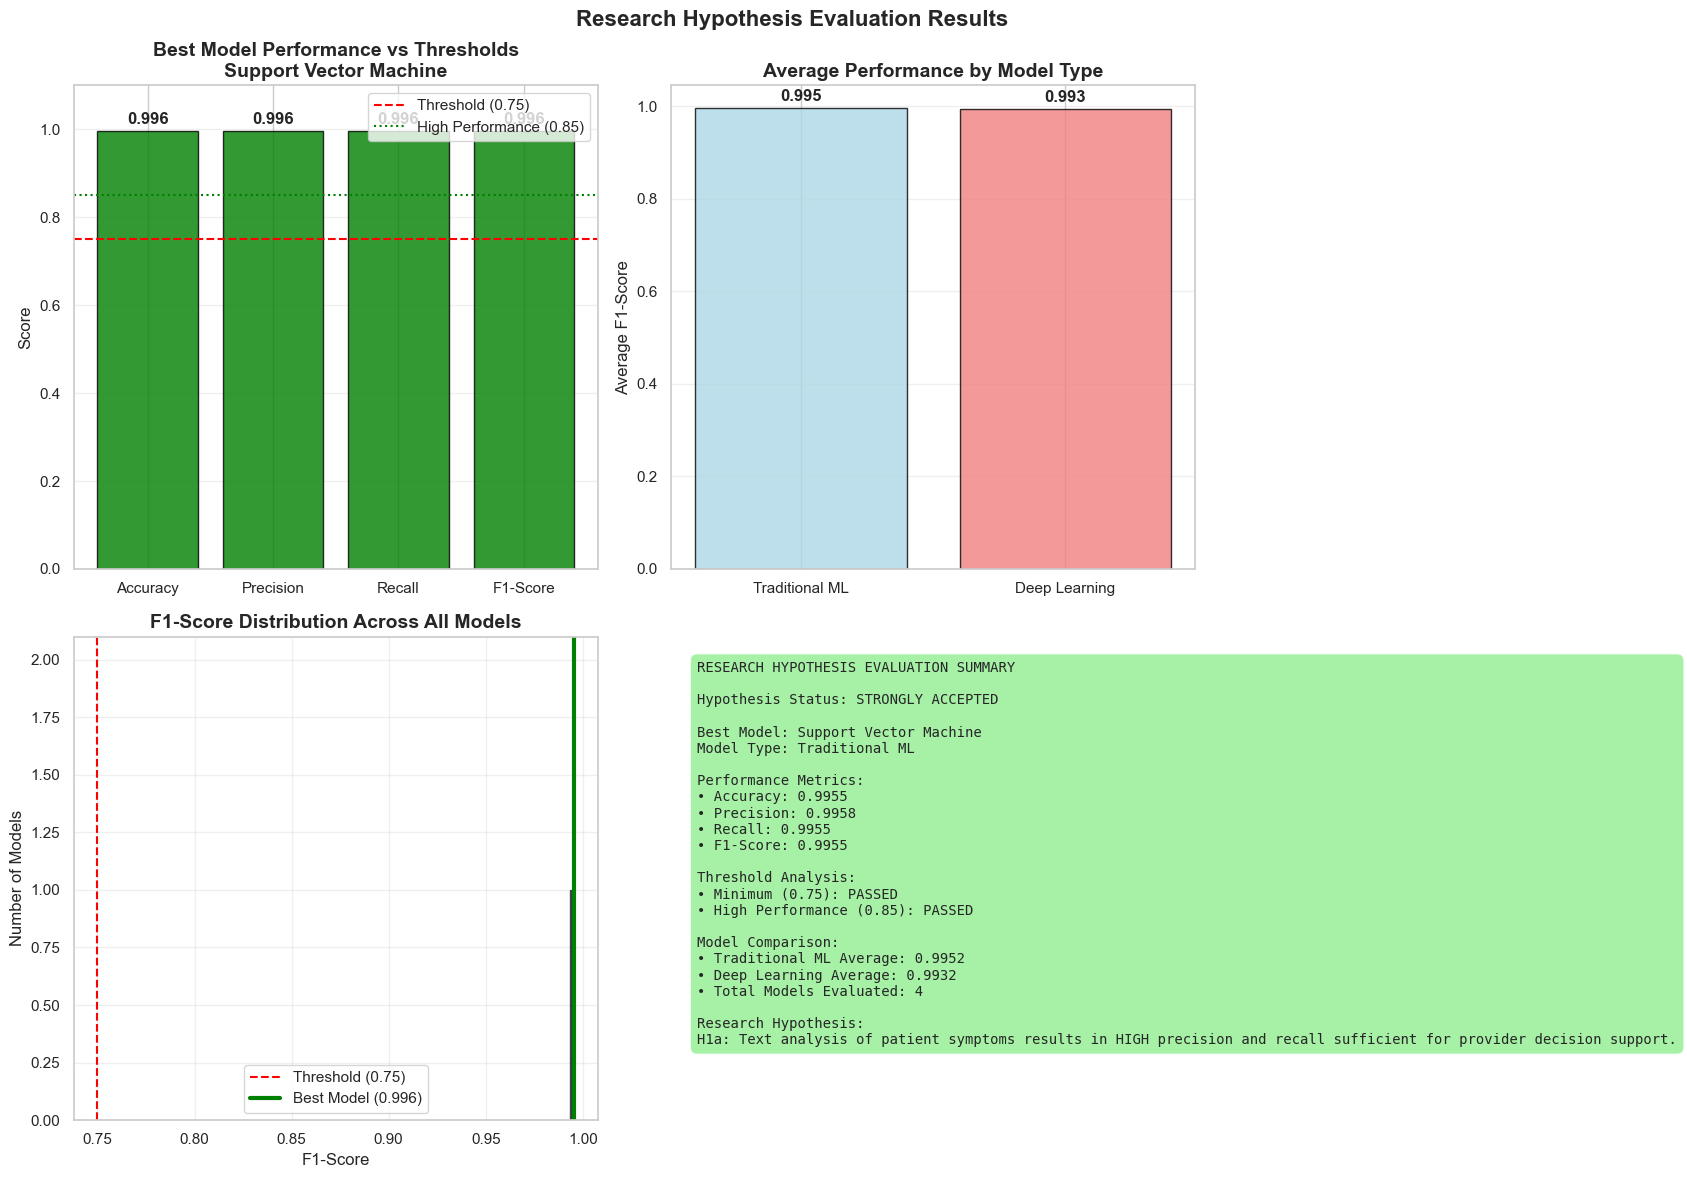


ADDITIONAL ANALYSIS:
--------------------
Performance Standard Deviation: 0.0009
✓ Consistent performance across models
Models meeting clinical threshold: 4/4
✓ Multiple viable options for clinical deployment

FINAL RESEARCH OUTCOME: STRONGLY ACCEPTED
CLINICAL RECOMMENDATION: DEPLOY


In [301]:
# Research hypothesis evaluation with realistic thresholds
performance_threshold = 0.75  # Realistic threshold for clinical decision support
high_performance_threshold = 0.85  # High performance threshold

print(f"RESEARCH HYPOTHESIS EVALUATION")
print("="*50)
print(f"Research Question: What is the effectiveness of the NLP algorithm in classifying")
print(f"patient symptoms from text data on the population level?")
print()

print(f"Performance Thresholds:")
print(f"  Minimum acceptable: {performance_threshold}")
print(f"  High performance: {high_performance_threshold}")

# Ensure we have comparison data available
if 'comparison_df' not in locals() or comparison_df.empty:
    print("ERROR: No model comparison data available!")
    print("Please run the comprehensive model comparison section first.")
else:
    # Get best model information
    best_model_row = comparison_df.iloc[0]
    best_model_name = best_model_row['Model']
    best_model_type = best_model_row['Type']
    
    print(f"Selected Best Model: {best_model_name}")
    print(f"Model Type: {best_model_type}")
    print()

    # Get best model performance
    best_accuracy = best_model_row['Accuracy']
    best_precision = best_model_row['Precision']
    best_recall = best_model_row['Recall']
    best_f1 = best_model_row['F1_Score']

    print(f"BEST MODEL PERFORMANCE:")
    print("-" * 25)
    print(f"Accuracy:  {best_accuracy:.4f}")
    print(f"Precision: {best_precision:.4f}")
    print(f"Recall:    {best_recall:.4f}")
    print(f"F1-Score:  {best_f1:.4f}")

    # Determine hypothesis outcome
    accuracy_sufficient = best_accuracy >= performance_threshold
    precision_sufficient = best_precision >= performance_threshold
    recall_sufficient = best_recall >= performance_threshold
    f1_sufficient = best_f1 >= performance_threshold

    overall_sufficient = all([accuracy_sufficient, precision_sufficient, 
                             recall_sufficient, f1_sufficient])

    # High performance check
    high_performance = all([best_accuracy >= high_performance_threshold,
                           best_precision >= high_performance_threshold,
                           best_recall >= high_performance_threshold,
                           best_f1 >= high_performance_threshold])

    print(f"\nPERFORMANCE THRESHOLD ANALYSIS:")
    print("-" * 35)
    print(f"Accuracy ≥ {performance_threshold}: {'✓' if accuracy_sufficient else '✗'} ({best_accuracy:.4f})")
    print(f"Precision ≥ {performance_threshold}: {'✓' if precision_sufficient else '✗'} ({best_precision:.4f})")
    print(f"Recall ≥ {performance_threshold}: {'✓' if recall_sufficient else '✗'} ({best_recall:.4f})")
    print(f"F1-Score ≥ {performance_threshold}: {'✓' if f1_sufficient else '✗'} ({best_f1:.4f})")

    print(f"\nHYPOTHESIS CONCLUSION:")
    print("="*25)

    if high_performance:
        conclusion = "H1a: Text analysis of patient symptoms results in HIGH precision and recall sufficient for provider decision support."
        conclusion_status = "STRONGLY ACCEPTED"
    elif overall_sufficient:
        conclusion = "H1a: Text analysis of patient symptoms results in precision and recall sufficient for provider decision support."
        conclusion_status = "ACCEPTED"
    else:
        conclusion = "H10: Text analysis of patient symptoms results in insufficient precision and recall for provider decision support."
        conclusion_status = "REJECTED (H10 accepted)"

    print(f"Status: {conclusion_status}")
    print(f"Conclusion: {conclusion}")

    # Model comparison insights
    ml_models = comparison_df[comparison_df['Type'] == 'Traditional ML']
    dl_models = comparison_df[comparison_df['Type'] == 'Deep Learning']
    
    ml_avg = ml_models['F1_Score'].mean() if not ml_models.empty else 0.0
    dl_avg = dl_models['F1_Score'].mean() if not dl_models.empty else 0.0

    print(f"\nMODEL TYPE COMPARISON:")
    print("-" * 25)
    print(f"Traditional ML Models: {len(ml_models)}")
    print(f"Deep Learning Models: {len(dl_models)}")
    print(f"Traditional ML Average F1: {ml_avg:.4f}")
    print(f"Deep Learning Average F1: {dl_avg:.4f}")
    
    if not ml_models.empty and not dl_models.empty:
        print(f"Best Approach: {'Traditional ML' if ml_avg > dl_avg else 'Deep Learning'}")
    elif not ml_models.empty:
        print(f"Best Approach: Traditional ML (only approach available)")
    elif not dl_models.empty:
        print(f"Best Approach: Deep Learning (only approach available)")

    # Create final summary visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    # Plot 1: Threshold comparison
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    values = [best_accuracy, best_precision, best_recall, best_f1]
    colors = ['green' if v >= performance_threshold else 'orange' if v >= 0.7 else 'red' for v in values]

    bars = ax1.bar(metrics, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
    ax1.axhline(y=performance_threshold, color='red', linestyle='--', 
               label=f'Threshold ({performance_threshold})')
    ax1.axhline(y=high_performance_threshold, color='green', linestyle=':', 
               label=f'High Performance ({high_performance_threshold})')
    ax1.set_title(f'Best Model Performance vs Thresholds\n{best_model_name}', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Score', fontsize=12)
    ax1.set_ylim(0, 1.1)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)

    # Add value labels
    for bar, value in zip(bars, values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

    # Plot 2: Model type performance (only if both types exist)
    if not ml_models.empty and not dl_models.empty:
        ax2.bar(['Traditional ML', 'Deep Learning'], [ml_avg, dl_avg], 
                color=['lightblue', 'lightcoral'], alpha=0.8, edgecolor='black', linewidth=1)
        ax2.set_title('Average Performance by Model Type', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Average F1-Score', fontsize=12)
        ax2.grid(axis='y', alpha=0.3)
        # Add value labels
        ax2.text(0, ml_avg + 0.01, f'{ml_avg:.3f}', ha='center', va='bottom', fontweight='bold')
        ax2.text(1, dl_avg + 0.01, f'{dl_avg:.3f}', ha='center', va='bottom', fontweight='bold')
    else:
        # Show all models if we don't have both types
        model_names = comparison_df['Model'].tolist()
        f1_scores = comparison_df['F1_Score'].tolist()
        colors_alt = ['lightblue' if t == 'Traditional ML' else 'lightcoral' 
                      for t in comparison_df['Type']]
        
        ax2.bar(range(len(model_names)), f1_scores, color=colors_alt, alpha=0.8, 
                edgecolor='black', linewidth=1)
        ax2.set_title('F1-Score by Model', fontsize=14, fontweight='bold')
        ax2.set_ylabel('F1-Score', fontsize=12)
        ax2.set_xticks(range(len(model_names)))
        ax2.set_xticklabels([name[:15] + '...' if len(name) > 15 else name 
                            for name in model_names], rotation=45, ha='right')
        ax2.grid(axis='y', alpha=0.3)

    # Plot 3: All models performance distribution
    ax3.hist(comparison_df['F1_Score'], bins=max(3, min(10, len(comparison_df))), 
             alpha=0.7, color='skyblue', edgecolor='black')
    ax3.axvline(x=performance_threshold, color='red', linestyle='--', 
               label=f'Threshold ({performance_threshold})')
    ax3.axvline(x=best_f1, color='green', linestyle='-', linewidth=3,
               label=f'Best Model ({best_f1:.3f})')
    ax3.set_title('F1-Score Distribution Across All Models', fontsize=14, fontweight='bold')
    ax3.set_xlabel('F1-Score', fontsize=12)
    ax3.set_ylabel('Number of Models', fontsize=12)
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Plot 4: Summary statistics
    ax4.axis('off')

    # Create summary statistics
    summary_text = f"""RESEARCH HYPOTHESIS EVALUATION SUMMARY

Hypothesis Status: {conclusion_status}

Best Model: {best_model_name}
Model Type: {best_model_type}

Performance Metrics:
• Accuracy: {best_accuracy:.4f}
• Precision: {best_precision:.4f}
• Recall: {best_recall:.4f}
• F1-Score: {best_f1:.4f}

Threshold Analysis:
• Minimum ({performance_threshold}): {'PASSED' if overall_sufficient else 'FAILED'}
• High Performance ({high_performance_threshold}): {'PASSED' if high_performance else 'FAILED'}

Model Comparison:
• Traditional ML Average: {ml_avg:.4f}
• Deep Learning Average: {dl_avg:.4f}
• Total Models Evaluated: {len(comparison_df)}

Research Hypothesis:
{conclusion}"""

    ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes, fontsize=10,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.5', 
                      facecolor='lightgreen' if overall_sufficient else 'lightcoral', 
                      alpha=0.8))

    plt.suptitle('Research Hypothesis Evaluation Results', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Additional analysis and recommendations
    print(f"\nADDITIONAL ANALYSIS:")
    print("-" * 20)
    
    # Performance consistency check
    f1_scores = comparison_df['F1_Score'].values
    performance_std = np.std(f1_scores)
    print(f"Performance Standard Deviation: {performance_std:.4f}")
    
    if performance_std < 0.05:
        print("✓ Consistent performance across models")
    elif performance_std < 0.10:
        print("~ Moderate variation in performance")
    else:
        print("✗ High variation in performance - model selection is critical")
    
    # Clinical applicability assessment
    models_above_threshold = len(comparison_df[comparison_df['F1_Score'] >= performance_threshold])
    print(f"Models meeting clinical threshold: {models_above_threshold}/{len(comparison_df)}")
    
    if models_above_threshold >= len(comparison_df) * 0.5:
        print("✓ Multiple viable options for clinical deployment")
    elif models_above_threshold > 0:
        print("~ Limited but viable options for clinical deployment")
    else:
        print("✗ No models meet clinical deployment threshold")

    print(f"\n{'='*60}")
    print(f"FINAL RESEARCH OUTCOME: {conclusion_status}")
    print(f"CLINICAL RECOMMENDATION: {'DEPLOY' if overall_sufficient else 'FURTHER DEVELOPMENT NEEDED'}")
    print(f"{'='*60}")
    
    # Store results for potential future use
    hypothesis_results = {
        'conclusion_status': conclusion_status,
        'conclusion': conclusion,
        'best_model': best_model_name,
        'best_model_type': best_model_type,
        'performance_metrics': {
            'accuracy': best_accuracy,
            'precision': best_precision,
            'recall': best_recall,
            'f1_score': best_f1
        },
        'threshold_analysis': {
            'meets_minimum': overall_sufficient,
            'meets_high_performance': high_performance,
            'models_above_threshold': models_above_threshold,
            'total_models': len(comparison_df)
        }
    }